<a href="https://colab.research.google.com/github/jaqueantunes/export_uva/blob/Clima/PosFIAP_Export.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd #1ª célula

In [ ]:
D1 = pd.read_csv('https://github.com/jaqueantunes/export_uva/raw/main/Bases/Comercio.csv', encoding='utf-8', skiprows=0, sep=';', skipfooter=12, thousands='.', decimal=',', engine='python')
D2 = pd.read_csv('https://github.com/jaqueantunes/export_uva/raw/main/Bases/ExpEspumantes.csv', encoding='utf-8', sep='\t')
D3 = pd.read_csv('https://github.com/jaqueantunes/export_uva/raw/main/Bases/ExpSuco.csv', encoding='utf-8', sep='\t')
D4 = pd.read_csv('https://github.com/jaqueantunes/export_uva/raw/main/Bases/ExpUva.csv', encoding='utf-8', sep='\t')
D5 = pd.read_csv('https://raw.githubusercontent.com/jaqueantunes/export_uva/main/Bases/ExpVinho.csv', encoding='utf-8', sep='\t')


## Análise inicial

In [ ]:
D5.head()

,Id,País,1970,1970.1,1971,1971.1,1972,1972.1,1973,1973.1,...,2020,2020.1,2021,2021.1,2022,2022.1,2023,2023.1,2024,2024.1
0,1,Afeganistão,0,0,0,0,0,0,0,0,...,0,0,11,46,0,0,0,0,0,0
1,2,África do Sul,0,0,0,0,0,0,0,0,...,4,21,0,0,0,0,117,698,103,1783
2,3,"Alemanha, República Democrática",0,0,0,0,4168,2630,12000,8250,...,6261,32605,2698,6741,7630,45367,4806,31853,6666,48095
3,4,Angola,0,0,0,0,0,0,0,0,...,0,0,0,0,4068,4761,0,0,0,0
4,5,Anguilla,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
D4.head()

,Id,País,1970,1970.1,1971,1971.1,1972,1972.1,1973,1973.1,...,2020,2020.1,2021,2021.1,2022,2022.1,2023,2023.1,2024,2024.1
0,1,Africa do Sul,0,0,0,0,0,0,0,0,...,44,152,0,0,0,0,30,136,0,0
1,2,"Alemanha, República Democrática",0,0,135,103,0,0,0,0,...,1371694,2791556,1461590,2569452,559012,1213303,1701887,4101648,807805,2269851
2,3,Angola,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,Antígua e Barbuda,0,0,0,0,0,0,0,0,...,304,1013,437,1349,253,999,260,1173,521,2562
4,5,Arabia Saudita,0,0,0,0,0,0,0,0,...,32325,95999,2818,14671,12224,53675,2234,19382,810,2823


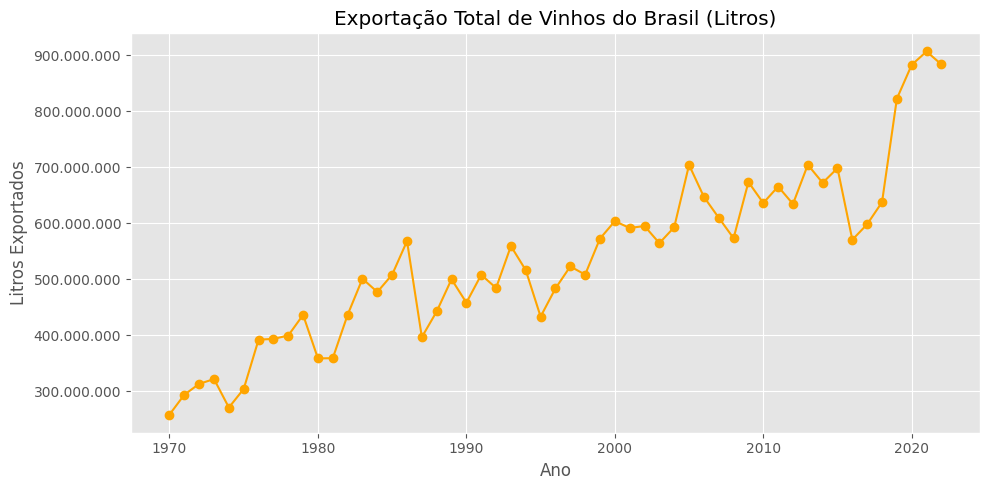

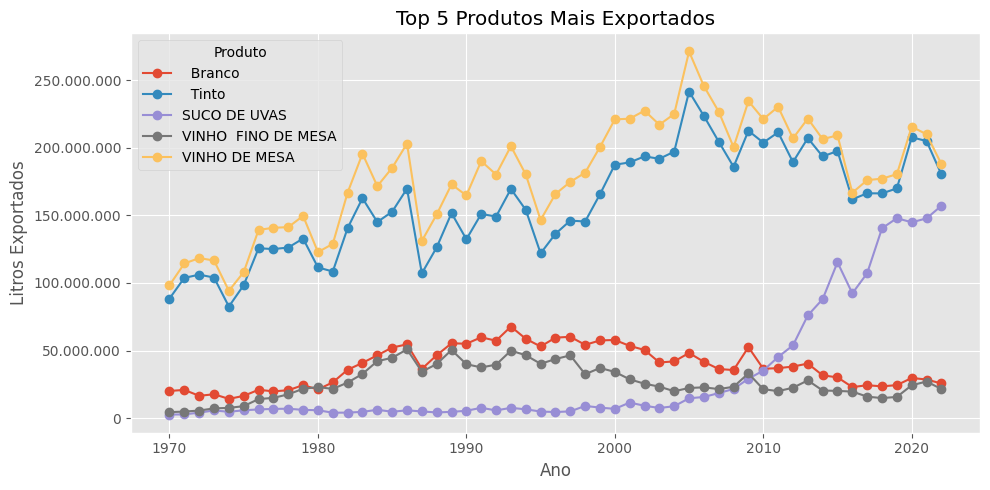

Ano com maior exportação: 2021 (906,843,284 litros)
Ano com menor exportação: 1970 (257,935,635 litros)


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Supondo que sua base já foi carregada no DataFrame `D1`

# 1. Seleciona apenas os anos desejados e as colunas relevantes
anos = [str(ano) for ano in range(1970, 2023)]  # sua base vai até 2021
dados_filtrados = D1[['control', 'Produto'] + anos]

# 2. Transforma para formato longo (long format)
dados_long = dados_filtrados.melt(
    id_vars=['control', 'Produto'],
    var_name='Ano',
    value_name='Litros'
)
dados_long['Ano'] = dados_long['Ano'].astype(int)
dados_long['Litros'] = pd.to_numeric(dados_long['Litros'], errors='coerce')

# 3. Agrupa por ano para resumo total
resumo_ano = dados_long.groupby('Ano')['Litros'].sum().reset_index(name='Total Litros Exportados')

# 4. Plota com eixo Y formatado
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(resumo_ano['Ano'], resumo_ano['Total Litros Exportados'], marker='o', color='orange')
ax.set_title('Exportação Total de Vinhos do Brasil (Litros)')
ax.set_xlabel('Ano')
ax.set_ylabel('Litros Exportados')

# 5. Formata o eixo Y com separador de milhar (ex: 300.000)
formatter = ticker.FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',', '.'))
ax.yaxis.set_major_formatter(formatter)

ax.grid(True)
plt.tight_layout()
plt.show()


import matplotlib.ticker as ticker

# Top 5 produtos mais exportados
top_produtos = dados_long.groupby('Produto')['Litros'].sum().sort_values(ascending=False).head(5).index
dados_top = dados_long[dados_long['Produto'].isin(top_produtos)]

# Pivot para gráfico
resumo_top = dados_top.groupby(['Ano', 'Produto'])['Litros'].sum().reset_index().pivot(index='Ano', columns='Produto', values='Litros')

# Gráfico formatado
ax = resumo_top.plot(figsize=(10, 5), marker='o', title='Top 5 Produtos Mais Exportados')
ax.set_xlabel('Ano')
ax.set_ylabel('Litros Exportados')

# Formata os números do eixo Y com separador de milhar
formatter = ticker.FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',', '.'))
ax.yaxis.set_major_formatter(formatter)

plt.grid(True)
plt.tight_layout()
plt.show()


# Cálculo do crescimento percentual ano a ano
resumo_ano['Crescimento (%)'] = resumo_ano['Total Litros Exportados'].pct_change() * 100

# Ano de maior e menor exportação
ano_max = resumo_ano.loc[resumo_ano['Total Litros Exportados'].idxmax()]
ano_min = resumo_ano.loc[resumo_ano['Total Litros Exportados'].idxmin()]
print(f"Ano com maior exportação: {int(ano_max['Ano'])} ({int(ano_max['Total Litros Exportados']):,} litros)")
print(f"Ano com menor exportação: {int(ano_min['Ano'])} ({int(ano_min['Total Litros Exportados']):,} litros)")


In [ ]:
print("Resumo por Produto (2009–2021):")
resumo_produto = dados_long.groupby('Produto')['Litros'].sum().reset_index(name='Total Litros Exportados')

display(resumo_produto)


Resumo por Produto (2009–2021):


,Produto,Total Litros Exportados
0,"Agrin (fermentado, acetico misto)",62379524
1,Aguardente de vinho 50°gl,871
2,Alcool vinico,84192
3,Bagaceira (graspa),14307637
4,Base champenoise champanha,643558
5,Base charmat champanha,1656893
6,Base espumante moscatel,1509744
7,Bebida de uva,28175705
8,Borra líquida,287011
9,Borra seca,2169365


##EXPORTAÇÃO


1.   Espumante
2.   Suco
3.   Uva
4.   Vinho



1. Espumante



In [ ]:
# Visualizando as primeiras linhas
D2.head()


,Id,País,1970,1970.1,1971,1971.1,1972,1972.1,1973,1973.1,...,2020,2020.1,2021,2021.1,2022,2022.1,2023,2023.1,2024,2024.1
0,1,África do Sul,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,2,44,78,1353
1,2,Alemanha,0,0,0,0,0,0,0,0,...,2388,14767,142,265,1164,6560,162,1542,22542,77981
2,3,Angola,0,0,0,0,0,0,0,0,...,24,38,0,0,26383,141588,56242,315073,0,0
3,4,Antigua e Barbuda,0,0,0,0,0,0,0,0,...,32,328,10,82,65,146,24,100,23,100
4,5,Antilhas Holandesas,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
print(sorted(D2['País'].dropna().unique()))


['Alemanha', 'Angola', 'Antigua e Barbuda', 'Antilhas Holandesas', 'Argentina', 'Aruba', 'Australia', 'Bahamas', 'Bangladesh', 'Barbados', 'Belgica', 'Benin', 'Bermudas', 'Bolívia', 'Bulgaria', 'Bósnia-Herzegovina', 'Cabo Verde', 'Camarões', 'Canada', 'Catar', 'Cayman, Ilhas', 'Chile', 'China', 'Chipre', 'Cingapura', 'Colombia', 'Coreia do Sul, Republica da', 'Costa Rica', 'Cuba', 'Curaçao', 'Dinamarca', 'Djibuti', 'Dominica', 'El Salvador', 'Emirados Arabes Unidos', 'Equador', 'Espanha', 'Estados Unidos', 'Estonia', 'Falkland (Malvinas)', 'Filipinas', 'Filânldia', 'França', 'Gana', 'Gibraltar', 'Granada', 'Grécia', 'Guatemala', 'Guiana', 'Guiné Equatorial', 'Guiné-Bissau', 'Haiti', 'Honduras', 'Hong Kong', 'Hungria', 'Ilha de Man', 'Iraque', 'Irlanda', 'Islândia', 'Itália', 'Japão', 'Jordânia', 'Letônia', 'Libéria', 'Luxemburgo', 'Líbano', 'Maldivas', 'Malta', 'Marrocos', 'Marshall, Ilhas', 'Montenegro', 'México', 'Nicarágua', 'Nigéria', 'Noruega', 'Nova Zelândia', 'Outros(1)', 'Panam

In [ ]:
# 1. Separar colunas de litros e valor
colunas_litros = [col for col in D2.columns if col.isdigit()]
colunas_valor = [col for col in D2.columns if '.1' in col]

# 2. Criar DataFrames separados e renomear
df_litros = D2[['País'] + colunas_litros].copy()
df_valor = D2[['País'] + colunas_valor].copy()
df_valor.columns = ['País'] + [col.replace('.1', '') for col in colunas_valor]

# 3. Transformar para formato longo
df_litros_long = df_litros.melt(id_vars='País', var_name='Ano', value_name='Litros')
df_valor_long = df_valor.melt(id_vars='País', var_name='Ano', value_name='Valor_USD')

# 4. Ajustar tipos e unir
df_litros_long['Ano'] = df_litros_long['Ano'].astype(int)
df_valor_long['Ano'] = df_valor_long['Ano'].astype(int)

df_comb = pd.merge(df_litros_long, df_valor_long, on=['País', 'Ano'], how='inner')

# 5. Filtrar últimos 15 anos (ajustável)
ano_max = df_comb['Ano'].max()
df_comb = df_comb[df_comb['Ano'] >= (ano_max - 14)]

# 6. Filtrar apenas linhas com litros > 0
df_comb = df_comb[df_comb['Litros'] > 0]

# 7. Calcular valor médio por litro
df_comb['USD_por_Litro'] = df_comb['Valor_USD'] / df_comb['Litros']

# 8. Visualizar
print("✔️ Dados prontos para análise. Total de linhas válidas:", len(df_comb))
display(df_comb.head())


✔️ Dados prontos para análise. Total de linhas válidas: 576


,País,Ano,Litros,Valor_USD,USD_por_Litro
4281,Alemanha,2010,1958,6877,3.512257
4282,Angola,2010,104138,672533,6.458094
4288,Bahamas,2010,146,795,5.445205
4291,Belgica,2010,12897,49742,3.856866
4294,Bolívia,2010,11960,5553,0.464298


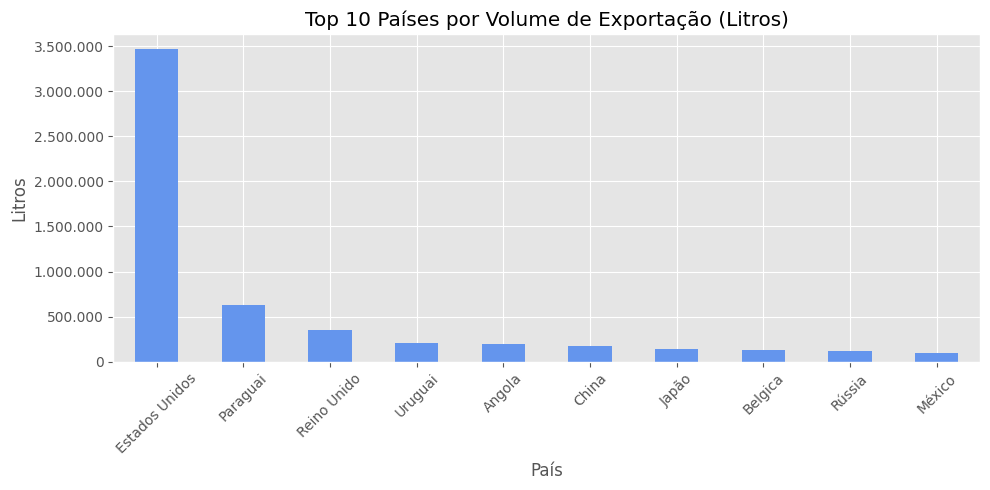

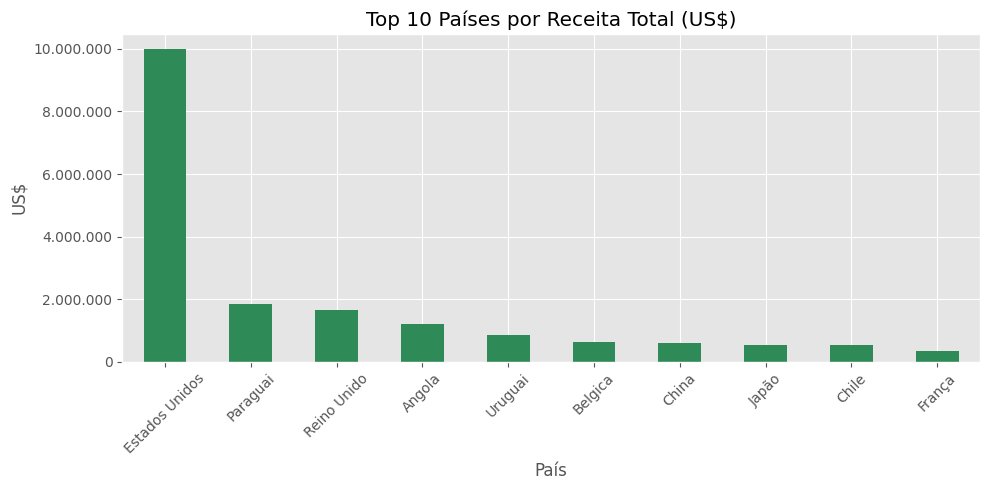

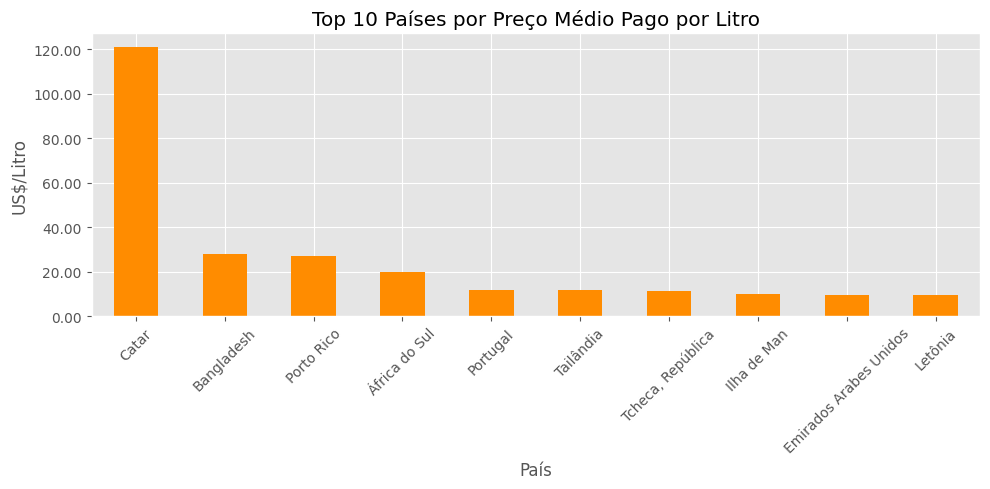

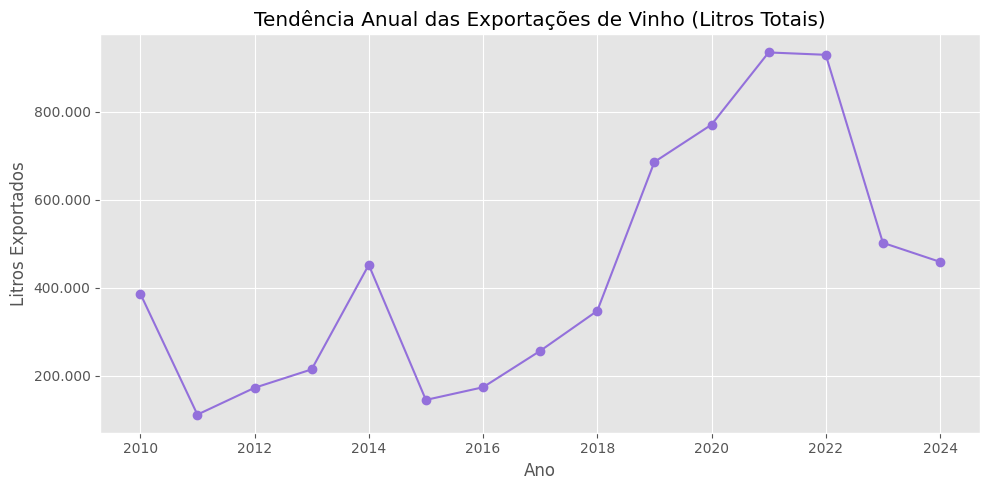

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# 1. Top 10 países por volume
top_litros = df_comb.groupby('País')['Litros'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
top_litros.plot(kind='bar', color='cornflowerblue')
plt.title('Top 10 Países por Volume de Exportação (Litros)')
plt.ylabel('Litros')
plt.xlabel('País')
plt.xticks(rotation=45)
plt.grid(True)
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',', '.')))
plt.tight_layout()
plt.show()

# 2. Top 10 países por receita total
top_valor = df_comb.groupby('País')['Valor_USD'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
top_valor.plot(kind='bar', color='seagreen')
plt.title('Top 10 Países por Receita Total (US$)')
plt.ylabel('US$')
plt.xlabel('País')
plt.xticks(rotation=45)
plt.grid(True)
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',', '.')))
plt.tight_layout()
plt.show()

# 3. Top 10 países que mais pagam por litro
top_preco = df_comb.groupby('País')['USD_por_Litro'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
top_preco.plot(kind='bar', color='darkorange')
plt.title('Top 10 Países por Preço Médio Pago por Litro')
plt.ylabel('US$/Litro')
plt.xlabel('País')
plt.xticks(rotation=45)
plt.grid(True)
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:,.2f}'.replace(',', '.')))
plt.tight_layout()
plt.show()

# 4. Tendência anual de exportações totais (em litros)
tendencia_anos = df_comb.groupby('Ano')['Litros'].sum()

plt.figure(figsize=(10, 5))
tendencia_anos.plot(marker='o', color='mediumpurple')
plt.title('Tendência Anual das Exportações de Vinho (Litros Totais)')
plt.ylabel('Litros Exportados')
plt.xlabel('Ano')
plt.grid(True)
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',', '.')))
plt.tight_layout()
plt.show()


In [ ]:
# Agrupar os dados por país
resumo_exec = df_comb.groupby('País').agg({
    'Litros': 'sum',
    'Valor_USD': 'sum'
}).reset_index()

# Calcular valor médio por litro
resumo_exec['USD_por_Litro'] = (resumo_exec['Valor_USD'] / resumo_exec['Litros']).round(2)

# Arredondar valores e formatar
resumo_exec['Litros'] = resumo_exec['Litros'].round(0).astype(int)
resumo_exec['Valor_USD'] = resumo_exec['Valor_USD'].round(0).astype(int)

# Ordenar pelos países com maior receita
resumo_exec = resumo_exec.sort_values(by='Valor_USD', ascending=False)

# Visualizar as 20 principais linhas
print(resumo_exec.head(20))


                       País   Litros  Valor_USD  USD_por_Litro
36           Estados Unidos  3463072    9982405           2.88
74                 Paraguai   632765    1857360           2.94
81              Reino Unido   349253    1652685           4.73
1                    Angola   201640    1193242           5.92
96                  Uruguai   213429     853210           4.00
10                  Belgica   130619     625253           4.79
21                    China   169935     586351           3.45
57                    Japão   140530     547043           3.89
20                    Chile    68091     523593           7.69
41                   França    47968     358364           7.47
0                  Alemanha    66678     323377           4.85
88                    Suíça    54567     299105           5.48
23                Cingapura    75992     263413           3.47
13                  Bolívia    85516     263088           3.08
79                 Portugal    29662     232815        

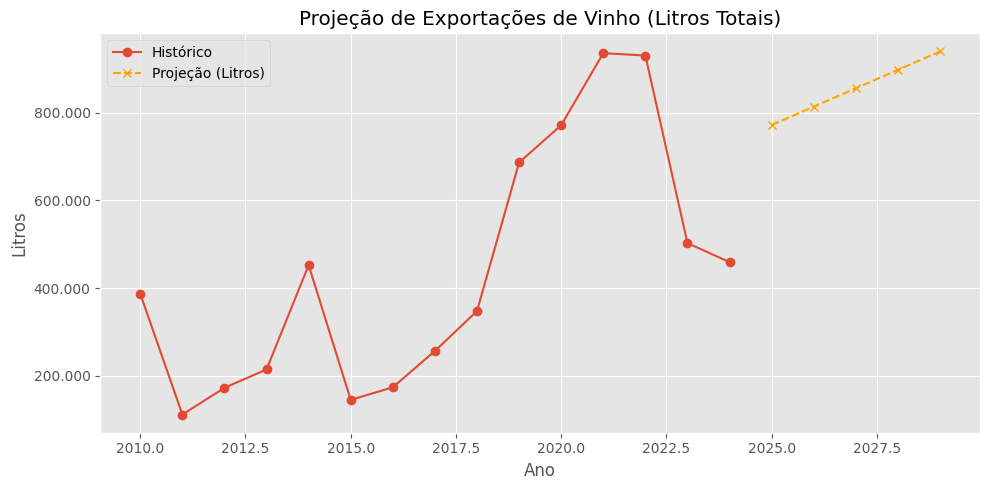

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import matplotlib.ticker as ticker

# Preparar dados dos últimos 15 anos
df_ultimos15 = df_comb[df_comb['Ano'] >= df_comb['Ano'].max() - 14]
df_ano = df_ultimos15.groupby('Ano').agg({'Litros': 'sum'}).reset_index()

# Treinamento da regressão linear
X = df_ano[['Ano']]
y = df_ano['Litros']
modelo = LinearRegression()
modelo.fit(X, y)

# Previsão para os próximos 5 anos
anos_futuros = pd.DataFrame({'Ano': np.arange(X['Ano'].max() + 1, X['Ano'].max() + 6)})
previsoes = modelo.predict(anos_futuros)

# Gráfico
plt.figure(figsize=(10, 5))
plt.plot(X['Ano'], y, label='Histórico', marker='o')
plt.plot(anos_futuros['Ano'], previsoes, '--x', label='Projeção (Litros)', color='orange')

plt.title('Projeção de Exportações de Vinho (Litros Totais)')
plt.xlabel('Ano')
plt.ylabel('Litros')
plt.grid(True)
plt.legend()
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',', '.')))
plt.tight_layout()
plt.show()


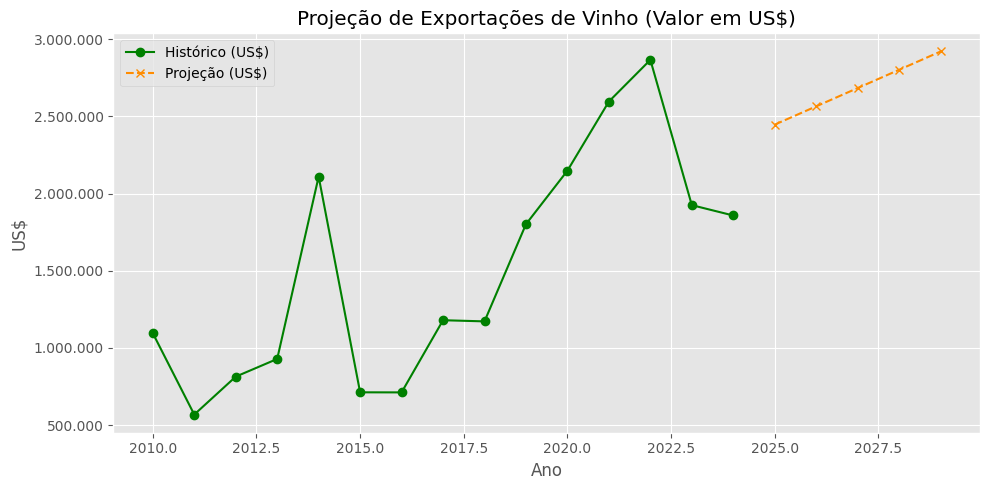

In [ ]:
# Preparar dados: total por ano (US$)
df_valor = df_ultimos15.groupby('Ano').agg({'Valor_USD': 'sum'}).reset_index()

# Modelo de regressão
X_valor = df_valor[['Ano']]
y_valor = df_valor['Valor_USD']
modelo_valor = LinearRegression()
modelo_valor.fit(X_valor, y_valor)

# Previsão para 5 anos
anos_futuros_valor = pd.DataFrame({'Ano': np.arange(X_valor['Ano'].max() + 1, X_valor['Ano'].max() + 6)})
previsoes_valor = modelo_valor.predict(anos_futuros_valor)

# Gráfico
plt.figure(figsize=(10, 5))
plt.plot(X_valor['Ano'], y_valor, label='Histórico (US$)', marker='o', color='green')
plt.plot(anos_futuros_valor['Ano'], previsoes_valor, '--x', label='Projeção (US$)', color='darkorange')

plt.title('Projeção de Exportações de Vinho (Valor em US$)')
plt.xlabel('Ano')
plt.ylabel('US$')
plt.grid(True)
plt.legend()
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',', '.')))
plt.tight_layout()
plt.show()


In [ ]:
# Histórico real (últimos 15 anos)
df_hist = df_ultimos15.groupby('Ano').agg({
    'Litros': 'sum',
    'Valor_USD': 'sum'
}).reset_index()

df_hist['USD_por_Litro'] = df_hist['Valor_USD'] / df_hist['Litros']

# Projeções (mesmo modelo que já usamos)
df_proj = pd.DataFrame({
    'Ano': anos_futuros_valor['Ano'],
    'Litros': modelo.predict(anos_futuros_valor),
    'Valor_USD': modelo_valor.predict(anos_futuros_valor)
})
df_proj['USD_por_Litro'] = df_proj['Valor_USD'] / df_proj['Litros']
df_proj['Fonte'] = 'Projeção'
df_hist['Fonte'] = 'Histórico'

# Junta tudo
df_total = pd.concat([df_hist, df_proj], ignore_index=True)

# Formatar visualmente (opcional)
df_total['Litros'] = df_total['Litros'].round(0).astype(int)
df_total['Valor_USD'] = df_total['Valor_USD'].round(0).astype(int)
df_total['USD_por_Litro'] = df_total['USD_por_Litro'].round(2)

# Exibir
import pandas as pd
from IPython.display import display
display(df_total)


,Ano,Litros,Valor_USD,USD_por_Litro,Fonte
0,2010,387160,1095632,2.83,Histórico
1,2011,111882,568390,5.08,Histórico
2,2012,172824,813909,4.71,Histórico
3,2013,214701,928626,4.33,Histórico
4,2014,452335,2109416,4.66,Histórico
5,2015,145282,712535,4.90,Histórico
6,2016,174049,711991,4.09,Histórico
7,2017,256746,1179471,4.59,Histórico
8,2018,347772,1171928,3.37,Histórico
9,2019,686270,1801326,2.62,Histórico


📈 O que esse código entrega:
Transforma sua base com nomes corrigidos;

Filtra os últimos 15 anos;

Cria modelos de regressão para Litros e Valor;

Gera um gráfico combinado com dois eixos:

Azul para Litros;

Verde para Valor em US$.


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



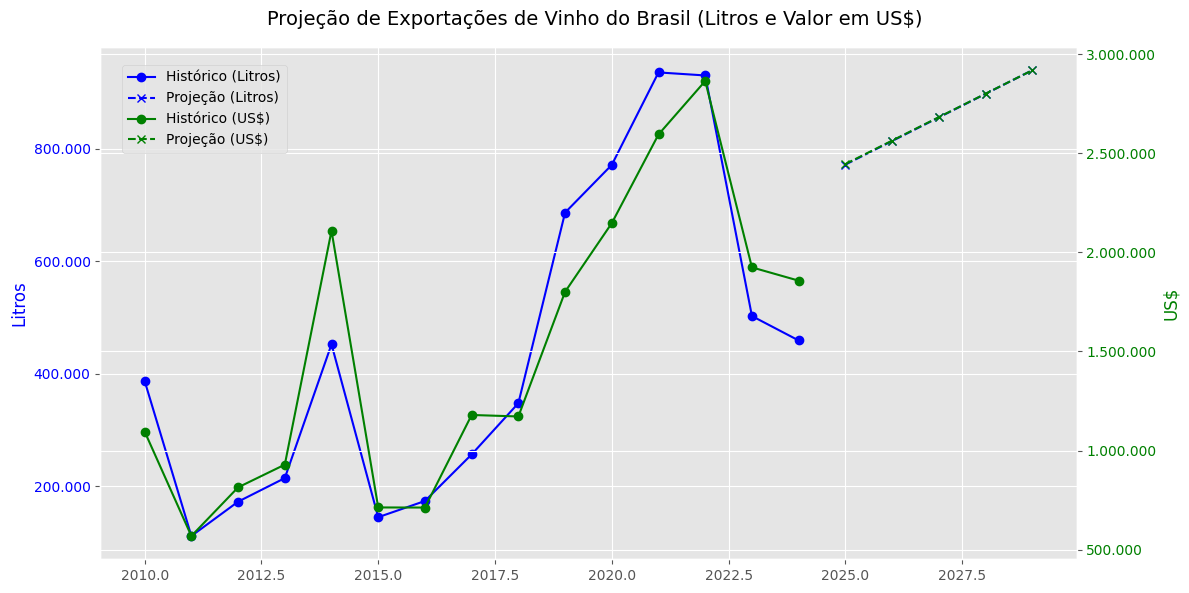

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import unicodedata

# Corrigir nome da coluna de país
D2.rename(columns={D2.columns[1]: 'País'}, inplace=True)

# Separar colunas
col_kg = [col for col in D2.columns if col.isdigit()]
col_usd = [col for col in D2.columns if '.1' in col]

# Renomear colunas de valor
D_valor = D2[['País'] + col_usd].copy()
D_valor.columns = ['País'] + [col.replace('.1', '') for col in col_usd]

# Transformar em formato longo
df_kg_long = D2[['País'] + col_kg].melt(id_vars='País', var_name='Ano', value_name='Litros')
df_valor_long = D_valor.melt(id_vars='País', var_name='Ano', value_name='Valor_USD')

# Ajustar tipos
df_kg_long['Ano'] = df_kg_long['Ano'].astype(int)
df_valor_long['Ano'] = df_valor_long['Ano'].astype(int)

# Normalizar nomes
def normalizar(texto):
    return unicodedata.normalize('NFKD', str(texto)).encode('ASCII', 'ignore').decode('utf-8').strip().lower()

df_kg_long['País'] = df_kg_long['País'].apply(normalizar)
df_valor_long['País'] = df_valor_long['País'].apply(normalizar)

# Combinar dados
df_comb = pd.merge(df_kg_long, df_valor_long, on=['País', 'Ano'], how='inner')
df_comb = df_comb[df_comb['Litros'] > 0]
df_comb['USD_por_Litro'] = df_comb['Valor_USD'] / df_comb['Litros']

# ========== PROJEÇÃO ==========
# Filtrar últimos 15 anos
ultimos_anos = sorted(df_comb['Ano'].unique())[-15:]
df_ultimos_15 = df_comb[df_comb['Ano'].isin(ultimos_anos)]

# Agrupar por ano
df_anual = df_ultimos_15.groupby('Ano')[['Litros', 'Valor_USD']].sum().reset_index()

# Regressão para projeção
X = df_anual[['Ano']]
anos_proj = np.array(range(2025, 2030)).reshape(-1, 1)

# Projeção Litros
modelo_litros = LinearRegression().fit(X, df_anual['Litros'])
proj_litros = modelo_litros.predict(anos_proj)

# Projeção Valor
modelo_valor = LinearRegression().fit(X, df_anual['Valor_USD'])
proj_valor = modelo_valor.predict(anos_proj)

# PLOT
fig, ax1 = plt.subplots(figsize=(12, 6))

# Litros
ax1.plot(df_anual['Ano'], df_anual['Litros'], label='Histórico (Litros)', color='blue', marker='o')
ax1.plot(anos_proj.flatten(), proj_litros, label='Projeção (Litros)', color='blue', linestyle='--', marker='x')
ax1.set_ylabel('Litros', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',', '.')))

# Valor
ax2 = ax1.twinx()
ax2.plot(df_anual['Ano'], df_anual['Valor_USD'], label='Histórico (US$)', color='green', marker='o')
ax2.plot(anos_proj.flatten(), proj_valor, label='Projeção (US$)', color='green', linestyle='--', marker='x')
ax2.set_ylabel('US$', color='green')
ax2.tick_params(axis='y', labelcolor='green')
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',', '.')))

# Finalizar gráfico
fig.suptitle('Projeção de Exportações de Vinho do Brasil (Litros e Valor em US$)', fontsize=14)
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
fig.tight_layout()
plt.show()


In [ ]:
# Mapeamento de países para continentes
mapa_continentes = {
    'brazil': 'América do Sul',
    'argentina': 'América do Sul',
    'uruguay': 'América do Sul',
    'paraguay': 'América do Sul',
    'chile': 'América do Sul',
    'colombia': 'América do Sul',
    'peru': 'América do Sul',
    'mexico': 'América do Norte',
    'united states': 'América do Norte',
    'canada': 'América do Norte',
    'germany': 'Europa',
    'france': 'Europa',
    'italy': 'Europa',
    'spain': 'Europa',
    'portugal': 'Europa',
    'belgium': 'Europa',
    'united kingdom': 'Europa',
    'netherlands': 'Europa',
    'china': 'Ásia',
    'japan': 'Ásia',
    'south korea': 'Ásia',
    'india': 'Ásia',
    'russia': 'Europa',
    'angola': 'África',
    'south africa': 'África',
    'nigeria': 'África',
    'australia': 'Oceania',
    'new zealand': 'Oceania',
    'unknown': 'Desconhecido',
    'trinidad and tobago': 'América do Norte',
    'netherlands antilles': 'América do Norte',
    'curacao': 'América do Norte',
    'antigua and barbuda': 'América do Norte',
    'bosnia and herzegovina': 'Europa',
    'isle of man': 'Europa',
    'africa do sul': 'África',
    'alemanha': 'Europa',
    'antigua e barbuda': 'América do Norte',
    'aruba': 'América do Norte',
    'bahamas': 'América do Norte',
    'bangladesh': 'Ásia',
    'barbados': 'América do Norte',
    'benin': 'África',
    'bermudas': 'América do Norte',
    'bolivia': 'América do Sul',
    'cabo verde': 'África',
    'camaraes': 'África',
    'catar': 'Ásia',
    'cayman, ilhas': 'América do Norte',
    'chipre': 'Europa',
    'costa rica': 'América do Norte',
    'cuba': 'América do Norte',
    'czech republic': 'Europa',
    'dinamarca': 'Europa',
    'djibuti': 'África',
    'dominica': 'América do Norte',
    'el salvador': 'América do Norte',
    'emirados arabes unidos': 'Ásia',
    'equador': 'América do Sul',
    'equatorial guinea': 'África',
    'estonia': 'Europa',
    'falkland (malvinas)': 'América do Sul',
    'filipinas': 'Ásia',
    'finland': 'Europa',
    'gana': 'África',
    'gibraltar': 'Europa',
    'granada': 'América do Norte',
    'greece': 'Europa',
    'guatemala': 'América do Norte',
    'guyana': 'América do Sul',
    'haiti': 'América do Norte',
    'honduras': 'América do Norte',
    'hong kong sar': 'Ásia',
    'hungria': 'Europa',
    'iceland': 'Europa',
    'iraque': 'Ásia',
    'irlanda': 'Europa',
    'jordania': 'Ásia',
    'latvia': 'Europa',
    'lebanon': 'Ásia',
    'liberia': 'África',
    'luxemburgo': 'Europa',
    'maldivas': 'Ásia',
    'malta': 'Europa',
    'marrocos': 'África',
    'marshall islands': 'Oceania',
    'montenegro': 'Europa',
    'nicaragua': 'América do Norte',
    'noruega': 'Europa',
    'panama': 'América do Norte',
    'poland': 'Europa',
    'porto rico': 'América do Norte',
    'republica dominicana': 'América do Norte',
    'republica tcheca': 'Europa',
    'serbia': 'Europa',
    'serra leoa': 'África',
    'singapore': 'Ásia',
    'sudan': 'África',
    'suriname': 'América do Sul',
    'sweden': 'Europa',
    'tailandia': 'Ásia',
    'taiwan (formosa)': 'Ásia',
    'togo': 'África',
    'trinidad and tobago': 'América do Norte',
    'turquia': 'Ásia',
    'unknown': 'Desconhecido',
    'vanuatu': 'Oceania',
    'venezuela': 'América do Sul',
    'vietnam': 'Ásia',
    }

# Criar coluna de continente
df_comb['Continente'] = df_comb['País'].map(mapa_continentes).fillna('Desconhecido')


In [ ]:
desconhecidos = df_comb[df_comb['Continente'] == 'Desconhecido']['País'].unique()
print("Países sem continente atribuído:")
for pais in sorted(desconhecidos):
    print("-", pais)


Países sem continente atribuído:
- antilhas holandesas
- belgica
- bosnia-herzegovina
- camaroes
- cingapura
- coreia do sul, republica da
- espanha
- estados unidos
- filanldia
- franca
- grecia
- guiana
- guine equatorial
- hong kong
- ilha de man
- islandia
- italia
- japao
- letonia
- libano
- marshall, ilhas
- nova zelandia
- outros(1)
- paises baixos (holanda)
- paraguai
- polonia
- quenia
- reino unido
- servia
- singapura
- suecia
- suica
- tcheca, republica
- trinidade e tobago
- uruguai
- vietna


In [ ]:
df_comb.loc[df_comb['País'] == 'unknown', 'Continente'] = 'Outros'

In [ ]:

# Verificar a distribuição por continente
print(df_comb['Continente'].value_counts())


Continente
Desconhecido        380
América do Norte    119
América do Sul      114
Europa              109
África               60
Ásia                 57
Oceania              13
Name: count, dtype: int64


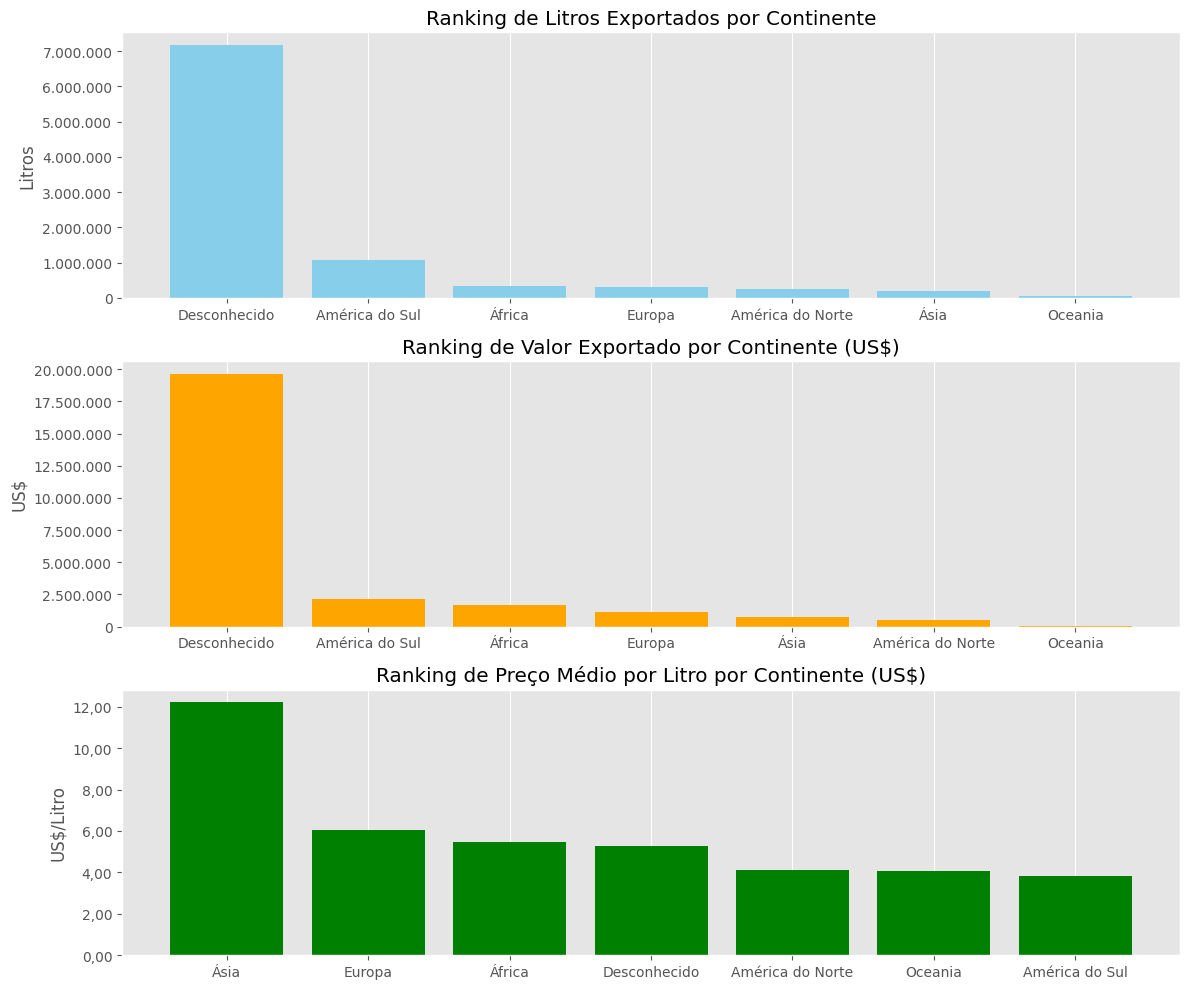

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# === Agrupar dados por continente ===
ranking_litros = df_comb.groupby('Continente')['Litros'].sum().sort_values(ascending=False)
ranking_valor = df_comb.groupby('Continente')['Valor_USD'].sum().sort_values(ascending=False)
ranking_preco_medio = df_comb.groupby('Continente')['USD_por_Litro'].mean().sort_values(ascending=False)

# === Criar gráfico ===
fig, axs = plt.subplots(3, 1, figsize=(12, 10))

# 1. Litros
axs[0].bar(ranking_litros.index, ranking_litros.values, color='skyblue')
axs[0].set_title('Ranking de Litros Exportados por Continente')
axs[0].set_ylabel('Litros')
axs[0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:,.0f}'.replace(',', '.')))
axs[0].grid(axis='y')

# 2. Valor em US$
axs[1].bar(ranking_valor.index, ranking_valor.values, color='orange')
axs[1].set_title('Ranking de Valor Exportado por Continente (US$)')
axs[1].set_ylabel('US$')
axs[1].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:,.0f}'.replace(',', '.')))
axs[1].grid(axis='y')

# 3. Preço Médio
axs[2].bar(ranking_preco_medio.index, ranking_preco_medio.values, color='green')
axs[2].set_title('Ranking de Preço Médio por Litro por Continente (US$)')
axs[2].set_ylabel('US$/Litro')
axs[2].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:,.2f}'.replace('.', ',')))
axs[2].grid(axis='y')

plt.tight_layout()
plt.show()


In [ ]:
from datetime import datetime

# Filtrar os últimos 15 anos
ano_limite = datetime.now().year - 15
df_recentes = df_comb[df_comb['Ano'] >= ano_limite]

# Calcular ranking por valor médio pago por litro
ranking_valor_medio = df_recentes.groupby('País')['USD_por_Litro']\
    .mean()\
    .sort_values(ascending=False)\
    .head(10)\
    .reset_index()

# Exibir resultado
print("Top 10 países que mais pagam por litro de vinho (últimos 15 anos):")
print(ranking_valor_medio)


Top 10 países que mais pagam por litro de vinho (últimos 15 anos):
                     País  USD_por_Litro
0                   catar     121.161288
1              bangladesh      28.000000
2              porto rico      26.848889
3           africa do sul      19.673077
4                portugal      11.648649
5               tailandia      11.590804
6       tcheca, republica      11.204765
7             ilha de man      10.000000
8  emirados arabes unidos       9.512012
9                 letonia       9.406275


In [ ]:
import pandas as pd
import plotly.express as px
import plotly.graph_objs as go

# 1. Evolução das exportações por continente ao longo dos anos
evolucao = df_comb.groupby(['Ano', 'Continente'])['Litros'].sum().reset_index()

fig1 = px.line(
    evolucao,
    x='Ano',
    y='Litros',
    color='Continente',
    title='Evolução das Exportações por Continente (Litros)',
    markers=True
)
fig1.show()

# 2. Comparação América do Norte vs Europa nos últimos 15 anos
ano_max = df_comb['Ano'].max()
ultimos_15 = df_comb[(df_comb['Ano'] >= ano_max - 14) &
                     (df_comb['Continente'].isin(['América do Norte', 'Europa']))]

comparacao = ultimos_15.groupby(['Ano', 'Continente'])['Litros'].sum().reset_index()

fig2 = px.line(
    comparacao,
    x='Ano',
    y='Litros',
    color='Continente',
    title='América do Norte vs Europa - Últimos 15 Anos',
    markers=True
)
fig2.show()

# 3. Análise dos países em crescimento e queda
cutoff = ano_max - 5
df_recente = df_comb[df_comb['Ano'] > cutoff].groupby('País')['Litros'].sum()
df_antiga = df_comb[(df_comb['Ano'] <= cutoff) & (df_comb['Ano'] > cutoff - 5)].groupby('País')['Litros'].sum()

df_var = (df_recente - df_antiga).dropna().sort_values(ascending=False)
crescimento = df_var.head(10).reset_index()
queda = df_var.tail(10).reset_index()

fig3 = go.Figure()
fig3.add_trace(go.Bar(x=crescimento['País'], y=crescimento['Litros'], name='Crescimento', marker_color='green'))
fig3.add_trace(go.Bar(x=queda['País'], y=queda['Litros'], name='Queda', marker_color='red'))
fig3.update_layout(
    title='Top Países com Crescimento e Queda nas Compras (Litros)',
    barmode='group',
    xaxis_title='País',
    yaxis_title='Variação de Litros'
)
fig3.show()



In [ ]:
df_comb

,País,Ano,Litros,Valor_USD,USD_por_Litro,Continente
14,bolivia,1970,36,24,0.666667,América do Sul
80,paraguai,1970,415,152,0.366265,Desconhecido
106,outros(1),1970,5132,3208,0.625097,Desconhecido
121,bolivia,1971,350,208,0.594286,América do Sul
187,paraguai,1971,160,86,0.537500,Desconhecido
...,...,...,...,...,...,...
5870,singapura,2024,309,1046,3.385113,Desconhecido
5872,suica,2024,26632,82852,3.110994,Desconhecido
5876,"tcheca, republica",2024,360,5403,15.008333,Desconhecido
5877,togo,2024,1890,10358,5.480423,África


In [ ]:
!pip install dash plotly pandas


In [ ]:
import dash
from dash import dcc, html
import plotly.express as px
import pandas as pd

# Carregar seus dados já prontos (supondo que df_comb já esteja preparado)
# df_comb deve conter: País, Ano, Litros, Valor_USD, USD_por_Litro, Continente

# Inicializar o app Dash
app = dash.Dash(__name__)

# Gráfico 1 - Evolução por continente
fig_evolucao = px.line(
    df_comb.groupby(['Ano', 'Continente'])['Litros'].sum().reset_index(),
    x='Ano', y='Litros', color='Continente',
    title='📈 Evolução das Exportações por Continente (Litros)'
)

# Gráfico 2 - América do Norte vs Europa nos últimos 15 anos
anos_recentes = sorted(df_comb['Ano'].unique())[-15:]
df_15anos = df_comb[df_comb['Ano'].isin(anos_recentes)]
df_2continentes = df_15anos[df_15anos['Continente'].isin(['América do Norte', 'Europa'])]
fig_comp = px.line(
    df_2continentes.groupby(['Ano', 'Continente'])['Litros'].sum().reset_index(),
    x='Ano', y='Litros', color='Continente',
    title='🇺🇸 América do Norte vs 🇪🇺 Europa (Últimos 15 anos)'
)

# Gráfico 3 - Países com maior crescimento e queda
df_crescimento = df_comb.groupby(['País', 'Ano'])['Litros'].sum().reset_index()
df_var = df_crescimento.groupby('País')['Litros'].agg(['first', 'last'])
df_var['Delta'] = df_var['last'] - df_var['first']
df_var = df_var.sort_values(by='Delta', ascending=False).reset_index()

fig_top = px.bar(df_var.head(10), x='País', y='Delta', title='📈 Top 10 Países em Crescimento')
fig_bottom = px.bar(df_var.tail(10), x='País', y='Delta', title='📉 Top 10 Países em Queda')

# Layout do dashboard
app.layout = html.Div(children=[
    html.H1('🌍 Dashboard Interativo - Exportações de Vinho do Brasil'),

    dcc.Graph(figure=fig_evolucao),
    dcc.Graph(figure=fig_comp),

    html.Div([
        dcc.Graph(figure=fig_top),
        dcc.Graph(figure=fig_bottom),
    ], style={'display': 'flex', 'gap': '20px'})
])

# Rodar app
if __name__ == '__main__':
    app.run(debug=True)



<IPython.core.display.Javascript object>

2. Suco

# Clima
Importanto dados de climatologia da cidade de Bento Gonçalves. Local onde é registrada a vinícola e pertencete à Serra Gaúcha, local de produção das bebidas aqui analisadas.

As informações foram coletadas do INMET.

In [ ]:
D_clima = pd.read_csv('https://raw.githubusercontent.com/jaqueantunes/export_uva/refs/heads/main/Bases%20externas/Clima%20-%20INMET%20-%20RS/dados_A840_D_2006-11-30_2024-12-31.csv', encoding='latin1', sep=';', on_bad_lines='skip', skiprows=[0,1,2,3,4,5,6,7, 8])

In [ ]:
D_clima.head()

,Data Medicao,"PRECIPITACAO TOTAL, DIARIO (AUT)(mm)","TEMPERATURA MAXIMA, DIARIA (AUT)(Â°C)","TEMPERATURA MEDIA, DIARIA (AUT)(Â°C)","TEMPERATURA MINIMA, DIARIA (AUT)(Â°C)","UMIDADE RELATIVA DO AR, MEDIA DIARIA (AUT)(%)","VENTO, VELOCIDADE MEDIA DIARIA (AUT)(m/s)",Unnamed: 7
0,2006-11-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2006-12-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2006-12-02,NaN,"29,3","22,8","17,2","54,4","4,1",NaN
3,2006-12-03,0,"30,3","24,3","18,3","60,4","2,6",NaN
4,2006-12-04,0,"28,7","24,1","21,4","67,7","2,8",NaN


In [ ]:
# Verificar se a coluna 'Unnamed' é totalmente NaN
coluna_toda_nan = D_clima['Unnamed: 7'].isna().all()

print(f"A coluna 'Unnamed:7' só tem NaN? {coluna_toda_nan}")

D_clima = D_clima.dropna(axis=1, how='all')

A coluna 'Unnamed:7' só tem NaN? True


In [ ]:
D_clima.head()

,Data Medicao,"PRECIPITACAO TOTAL, DIARIO (AUT)(mm)","TEMPERATURA MAXIMA, DIARIA (AUT)(Â°C)","TEMPERATURA MEDIA, DIARIA (AUT)(Â°C)","TEMPERATURA MINIMA, DIARIA (AUT)(Â°C)","UMIDADE RELATIVA DO AR, MEDIA DIARIA (AUT)(%)","VENTO, VELOCIDADE MEDIA DIARIA (AUT)(m/s)"
0,2006-11-30,NaN,NaN,NaN,NaN,NaN,NaN
1,2006-12-01,NaN,NaN,NaN,NaN,NaN,NaN
2,2006-12-02,NaN,"29,3","22,8","17,2","54,4","4,1"
3,2006-12-03,0,"30,3","24,3","18,3","60,4","2,6"
4,2006-12-04,0,"28,7","24,1","21,4","67,7","2,8"


Considerando que a produção de uva tem valores climatológicos ótimos para a melhor produção possível, alguns dados serão utilizados como referência (buscas da internet).

Temperatura ótima ~16-20˚C

In [ ]:
print(D_clima.dtypes)

Data Medicao                                     object
PRECIPITACAO TOTAL, DIARIO (AUT)(mm)             object
TEMPERATURA MAXIMA, DIARIA (AUT)(Â°C)            object
TEMPERATURA MEDIA, DIARIA (AUT)(Â°C)             object
TEMPERATURA MINIMA, DIARIA (AUT)(Â°C)            object
UMIDADE RELATIVA DO AR, MEDIA DIARIA (AUT)(%)    object
VENTO, VELOCIDADE MEDIA DIARIA (AUT)(m/s)        object
dtype: object


In [ ]:
# Trocando o índice pra facilitar o gráfico
D_clima = D_clima.set_index('Data Medicao')

In [ ]:
D_clima.head()

,"PRECIPITACAO TOTAL, DIARIO (AUT)(mm)","TEMPERATURA MAXIMA, DIARIA (AUT)(Â°C)","TEMPERATURA MEDIA, DIARIA (AUT)(Â°C)","TEMPERATURA MINIMA, DIARIA (AUT)(Â°C)","UMIDADE RELATIVA DO AR, MEDIA DIARIA (AUT)(%)","VENTO, VELOCIDADE MEDIA DIARIA (AUT)(m/s)"
Data Medicao,,,,,,
2006-11-30,NaN,NaN,NaN,NaN,NaN,NaN
2006-12-01,NaN,NaN,NaN,NaN,NaN,NaN
2006-12-02,NaN,"29,3","22,8","17,2","54,4","4,1"
2006-12-03,0,"30,3","24,3","18,3","60,4","2,6"
2006-12-04,0,"28,7","24,1","21,4","67,7","2,8"


In [ ]:
cols = ['PRECIPITACAO TOTAL, DIARIO (AUT)(mm)',
        'TEMPERATURA MAXIMA, DIARIA (AUT)(Â°C)',
        'TEMPERATURA MEDIA, DIARIA (AUT)(Â°C)',
        'TEMPERATURA MINIMA, DIARIA (AUT)(Â°C)',
        'UMIDADE RELATIVA DO AR, MEDIA DIARIA (AUT)(%)',
        'VENTO, VELOCIDADE MEDIA DIARIA (AUT)(m/s)']

In [ ]:
D_clima[cols] = D_clima[cols].apply(pd.to_numeric, errors='coerce')

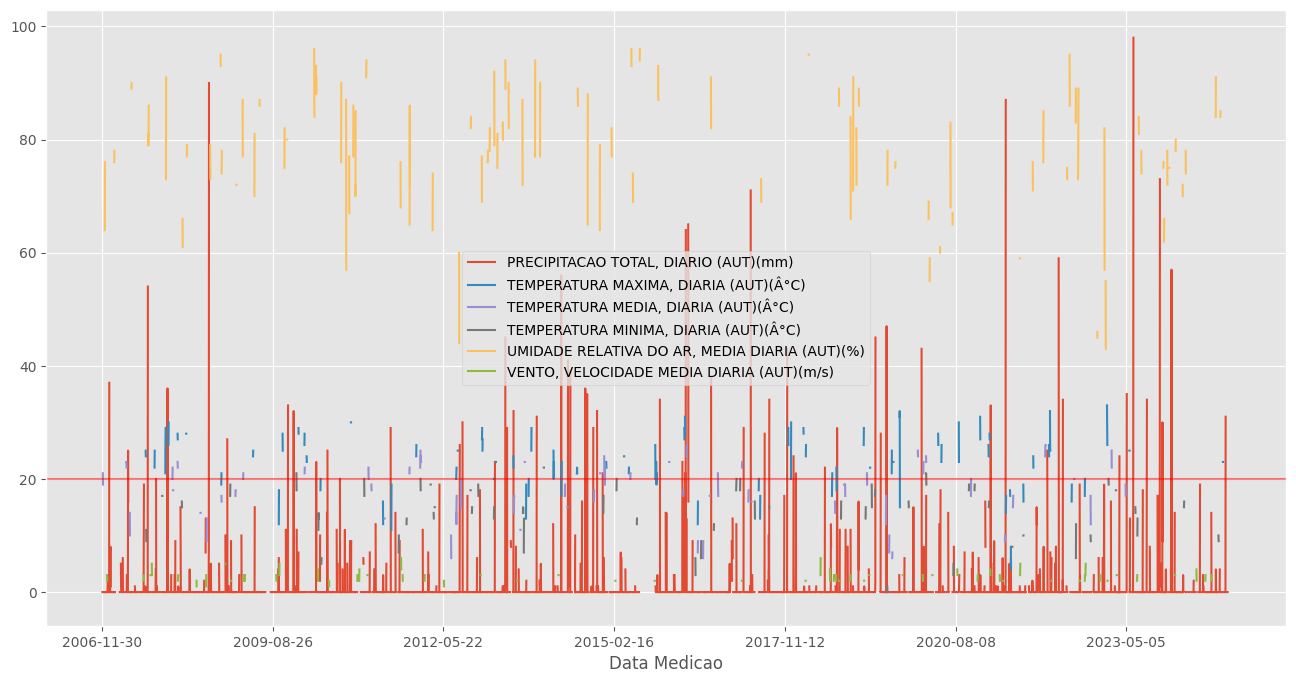

In [ ]:
D_clima.plot(figsize=[16,8]).axhline(20, color='red', alpha=0.5)

In [ ]:
## 1. Verificar e preparar os dados
# Certificar que o índice é datetime
D_clima.index = pd.to_datetime(D_clima.index)

# Substituir vírgulas por pontos e converter para float (se necessário)
for col in D_clima.columns:
    if D_clima[col].dtype == 'object':
        D_clima[col] = D_clima[col].astype(str).str.replace(',', '.').astype(float)

## 2. Agrupar por ano e calcular estatísticas
# Criar DataFrame agrupado por ano
df_clima_anual = pd.DataFrame()

# Precipitação - soma anual e média diária
df_clima_anual['Precipitacao Total (mm)'] = D_clima['PRECIPITACAO TOTAL, DIARIO (AUT)(mm)'].groupby(D_clima.index.year).sum()
df_clima_anual['Precipitacao Media (mm/dia)'] = D_clima['PRECIPITACAO TOTAL, DIARIO (AUT)(mm)'].groupby(D_clima.index.year).mean()

# Temperaturas - médias anuais e extremos
df_clima_anual['Temp Max Media (°C)'] = D_clima['TEMPERATURA MAXIMA, DIARIA (AUT)(Â°C)'].groupby(D_clima.index.year).mean()
df_clima_anual['Temp Max Absoluta (°C)'] = D_clima['TEMPERATURA MAXIMA, DIARIA (AUT)(Â°C)'].groupby(D_clima.index.year).max()
df_clima_anual['Temp Media (°C)'] = D_clima['TEMPERATURA MEDIA, DIARIA (AUT)(Â°C)'].groupby(D_clima.index.year).mean()
df_clima_anual['Temp Min Media (°C)'] = D_clima['TEMPERATURA MINIMA, DIARIA (AUT)(Â°C)'].groupby(D_clima.index.year).mean()
df_clima_anual['Temp Min Absoluta (°C)'] = D_clima['TEMPERATURA MINIMA, DIARIA (AUT)(Â°C)'].groupby(D_clima.index.year).min()

# Umidade e Vento - médias anuais
df_clima_anual['Umidade Media (%)'] = D_clima['UMIDADE RELATIVA DO AR, MEDIA DIARIA (AUT)(%)'].groupby(D_clima.index.year).mean()
df_clima_anual['Vento Medio (m/s)'] = D_clima['VENTO, VELOCIDADE MEDIA DIARIA (AUT)(m/s)'].groupby(D_clima.index.year).mean()

## 3. Limpar e formatar o resultado
# Resetar o índice para ter 'Ano' como coluna
df_clima_anual = df_clima_anual.reset_index().rename(columns={'index': 'Ano'})

# Arredondar valores para 1 casa decimal
df_clima_anual = df_clima_anual.round(1)

# Mostrar o resultado
print(df_clima_anual.head())

   Data Medicao  Precipitacao Total (mm)  Precipitacao Media (mm/dia)  \
0          2006                      0.0                          0.0   
1          2007                    315.0                          1.5   
2          2008                    260.0                          1.1   
3          2009                    169.0                          0.8   
4          2010                    266.0                          1.2   

   Temp Max Media (°C)  Temp Max Absoluta (°C)  Temp Media (°C)  \
0                 29.3                    31.0             21.6   
1                 23.4                    31.0             16.9   
2                 22.8                    32.0             17.0   
3                 22.4                    32.0             17.8   
4                 23.4                    34.0             16.9   

   Temp Min Media (°C)  Temp Min Absoluta (°C)  Umidade Media (%)  \
0                 18.5                    15.0               70.0   
1                 13

In [ ]:
df_clima_anual

,Data Medicao,Precipitacao Total (mm),Precipitacao Media (mm/dia),Temp Max Media (°C),Temp Max Absoluta (°C),Temp Media (°C),Temp Min Media (°C),Temp Min Absoluta (°C),Umidade Media (%),Vento Medio (m/s)
0,2006,0.0,0.0,29.3,31.0,21.6,18.5,15.0,70.0,3.0
1,2007,315.0,1.5,23.4,31.0,16.9,13.9,3.0,79.0,3.0
2,2008,260.0,1.1,22.8,32.0,17.0,12.8,1.0,76.2,2.7
3,2009,169.0,0.8,22.4,32.0,17.8,14.1,5.0,79.3,2.5
4,2010,266.0,1.2,23.4,34.0,16.9,13.6,5.0,79.7,2.5
5,2011,184.0,0.9,21.5,33.0,17.4,13.1,-1.0,74.8,2.7
6,2012,197.0,0.7,23.0,32.0,17.8,15.4,2.0,74.0,2.9
7,2013,319.0,1.4,23.1,35.0,17.7,13.5,3.0,78.1,2.6
8,2014,574.0,2.6,23.5,34.0,18.2,16.0,4.0,77.5,3.1
9,2015,178.0,1.1,23.9,32.0,17.9,16.2,11.0,83.2,2.8


In [ ]:
# Trocando o índice pra facilitar o gráfico
df_clima_anual_analise = df_clima_anual.set_index('Data Medicao')

In [ ]:
df_clima_anual

,Data Medicao,Precipitacao Total (mm),Precipitacao Media (mm/dia),Temp Max Media (°C),Temp Max Absoluta (°C),Temp Media (°C),Temp Min Media (°C),Temp Min Absoluta (°C),Umidade Media (%),Vento Medio (m/s)
0,2006,0.0,0.0,29.3,31.0,21.6,18.5,15.0,70.0,3.0
1,2007,315.0,1.5,23.4,31.0,16.9,13.9,3.0,79.0,3.0
2,2008,260.0,1.1,22.8,32.0,17.0,12.8,1.0,76.2,2.7
3,2009,169.0,0.8,22.4,32.0,17.8,14.1,5.0,79.3,2.5
4,2010,266.0,1.2,23.4,34.0,16.9,13.6,5.0,79.7,2.5
5,2011,184.0,0.9,21.5,33.0,17.4,13.1,-1.0,74.8,2.7
6,2012,197.0,0.7,23.0,32.0,17.8,15.4,2.0,74.0,2.9
7,2013,319.0,1.4,23.1,35.0,17.7,13.5,3.0,78.1,2.6
8,2014,574.0,2.6,23.5,34.0,18.2,16.0,4.0,77.5,3.1
9,2015,178.0,1.1,23.9,32.0,17.9,16.2,11.0,83.2,2.8


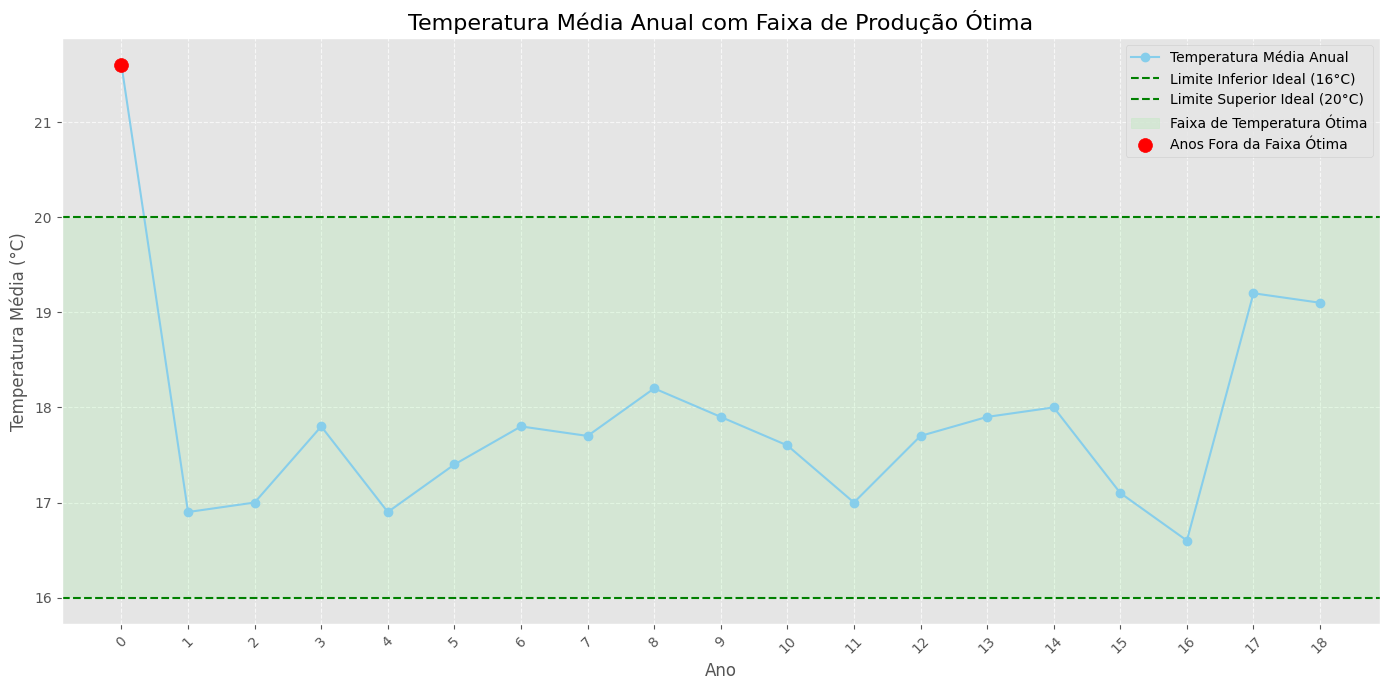


Anos em que a temperatura média anual não esteve na faixa ótima (16-20°C):
[0]


In [ ]:
import matplotlib.ticker as mticker # Para formatar os ticks do eixo X

# --- 1. Preparação dos Dados ---
df_clima_para_graficos = pd.DataFrame(df_clima_anual)

# Se o índice do seu DF não for int, rode esta linha ANTES dos gráficos:
# df_clima_para_graficos.index = df_clima_para_graficos.index.astype(int)


# --- Gráfico 1: Temperatura Média Anual com Faixa Ótima ---
fig, ax_temp_media = plt.subplots(figsize=(14, 7))

# Limites ideais de temperatura
limite_inferior_temp = 16
limite_superior_temp = 20

# Plotar a temperatura média
ax_temp_media.plot(df_clima_para_graficos.index,
                   df_clima_para_graficos['Temp Media (°C)'],
                   marker='o', linestyle='-', color='skyblue',
                   label='Temperatura Média Anual')

# Linhas dos limites ideais
ax_temp_media.axhline(y=limite_inferior_temp, color='green', linestyle='--',
                      label=f'Limite Inferior Ideal ({limite_inferior_temp}°C)')
ax_temp_media.axhline(y=limite_superior_temp, color='green', linestyle='--',
                      label=f'Limite Superior Ideal ({limite_superior_temp}°C)')

# Preencher a faixa ótima
ax_temp_media.axhspan(ymin=limite_inferior_temp, ymax=limite_superior_temp,
                      color='lightgreen', alpha=0.2, label='Faixa de Temperatura Ótima')

# Destacar anos fora da faixa
anos_fora_faixa_temp = df_clima_para_graficos[(df_clima_para_graficos['Temp Media (°C)'] < limite_inferior_temp) |
                                              (df_clima_para_graficos['Temp Media (°C)'] > limite_superior_temp)]
ax_temp_media.scatter(anos_fora_faixa_temp.index,
                      anos_fora_faixa_temp['Temp Media (°C)'],
                      color='red', s=100, zorder=5, label='Anos Fora da Faixa Ótima')

# Configurações do gráfico
ax_temp_media.set_title('Temperatura Média Anual com Faixa de Produção Ótima', fontsize=16)
ax_temp_media.set_xlabel('Ano', fontsize=12)
ax_temp_media.set_ylabel('Temperatura Média (°C)', fontsize=12)
ax_temp_media.set_xticks(df_clima_para_graficos.index.tolist()) # Garante todos os anos no eixo X
ax_temp_media.tick_params(axis='x', rotation=45, labelsize=10)
ax_temp_media.xaxis.set_major_formatter(mticker.FormatStrFormatter('%d')) # Formata como inteiro
ax_temp_media.grid(True, linestyle='--', alpha=0.7)
ax_temp_media.legend(loc='upper right')
plt.tight_layout()
plt.show()

print("\nAnos em que a temperatura média anual não esteve na faixa ótima (16-20°C):")
print(anos_fora_faixa_temp.index.tolist())

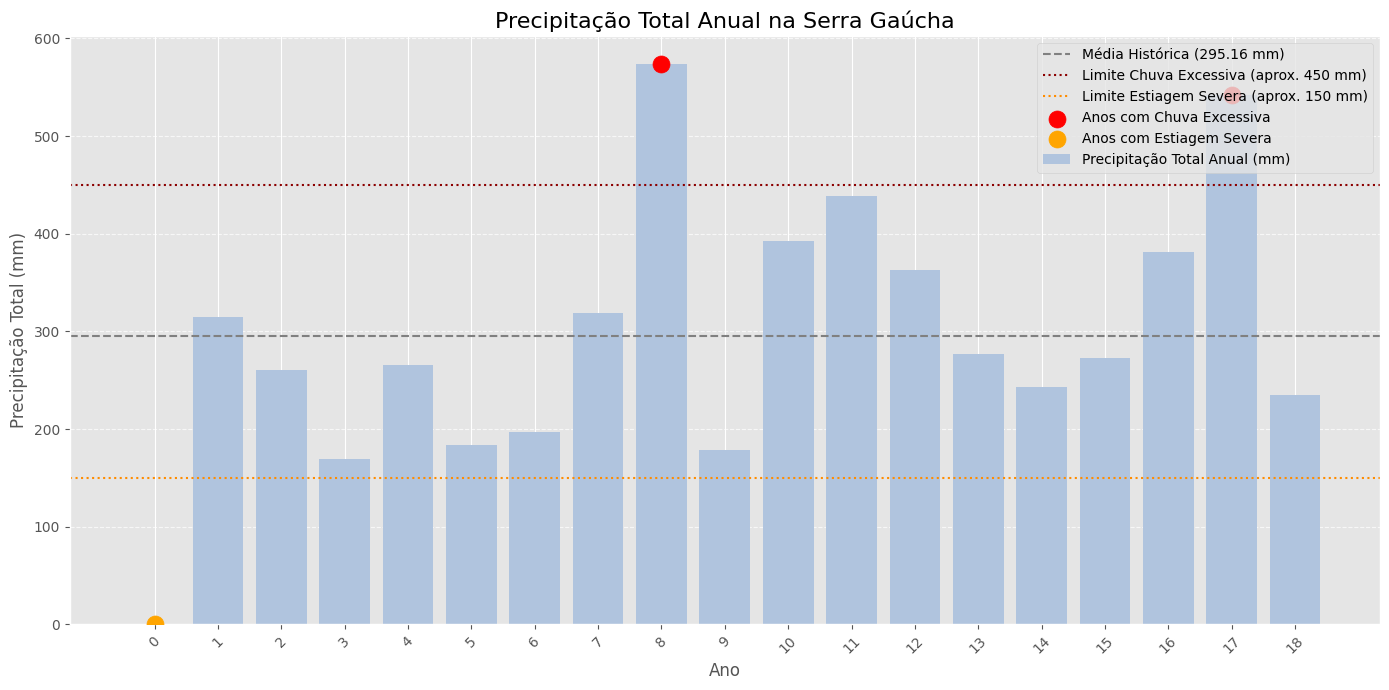


Anos com Precipitação Total Anual acima do limite de chuva excessiva (> 450mm):
[8, 17]

Anos com Precipitação Total Anual abaixo do limite de estiagem severa (< 150mm):
[0]


In [ ]:
# --- Gráfico 2: Precipitação Total Anual com Limites ---

fig, ax_precipitacao = plt.subplots(figsize=(14, 7))

# Plotar as barras de precipitação
# CORRIGIDO: O nome da coluna foi ajustado de 'Precipitação Total (mm)' para 'Precipitacao Total (mm)'
ax_precipitacao.bar(df_clima_para_graficos.index,
                    df_clima_para_graficos['Precipitacao Total (mm)'],
                    color='lightsteelblue',
                    label='Precipitação Total Anual (mm)')

# Limites de precipitação (ajuste conforme seu conhecimento da viticultura)
media_precipitacao_historica = df_clima_para_graficos['Precipitacao Total (mm)'].mean()
limite_chuva_excessiva = 450 # mm
limite_estiagem = 150 # mm

# Linhas de referência
ax_precipitacao.axhline(y=media_precipitacao_historica, color='grey', linestyle='--',
                        label=f'Média Histórica ({media_precipitacao_historica:.2f} mm)')
ax_precipitacao.axhline(y=limite_chuva_excessiva, color='darkred', linestyle=':',
                        label=f'Limite Chuva Excessiva (aprox. {limite_chuva_excessiva} mm)')
ax_precipitacao.axhline(y=limite_estiagem, color='darkorange', linestyle=':',
                        label=f'Limite Estiagem Severa (aprox. {limite_estiagem} mm)')

# Destacar anos fora dos limites
anos_chuva_excessiva = df_clima_para_graficos[df_clima_para_graficos['Precipitacao Total (mm)'] > limite_chuva_excessiva]
anos_estiagem_severa = df_clima_para_graficos[df_clima_para_graficos['Precipitacao Total (mm)'] < limite_estiagem]

ax_precipitacao.scatter(anos_chuva_excessiva.index,
                        anos_chuva_excessiva['Precipitacao Total (mm)'], # Corrigido aqui também
                        color='red', s=150, zorder=5, label='Anos com Chuva Excessiva')
ax_precipitacao.scatter(anos_estiagem_severa.index,
                        anos_estiagem_severa['Precipitacao Total (mm)'], # Corrigido aqui também
                        color='orange', s=150, zorder=5, label='Anos com Estiagem Severa')

# Configurações do gráfico
ax_precipitacao.set_title('Precipitação Total Anual na Serra Gaúcha', fontsize=16)
ax_precipitacao.set_xlabel('Ano', fontsize=12)
ax_precipitacao.set_ylabel('Precipitação Total (mm)', fontsize=12)
ax_precipitacao.set_xticks(df_clima_para_graficos.index.tolist())
ax_precipitacao.tick_params(axis='x', rotation=45, labelsize=10)
ax_precipitacao.xaxis.set_major_formatter(mticker.FormatStrFormatter('%d'))
ax_precipitacao.grid(axis='y', linestyle='--', alpha=0.7)
ax_precipitacao.legend(loc='upper right')
plt.tight_layout()
plt.show()

print("\nAnos com Precipitação Total Anual acima do limite de chuva excessiva (> 450mm):")
print(anos_chuva_excessiva.index.tolist())
print("\nAnos com Precipitação Total Anual abaixo do limite de estiagem severa (< 150mm):")
print(anos_estiagem_severa.index.tolist())

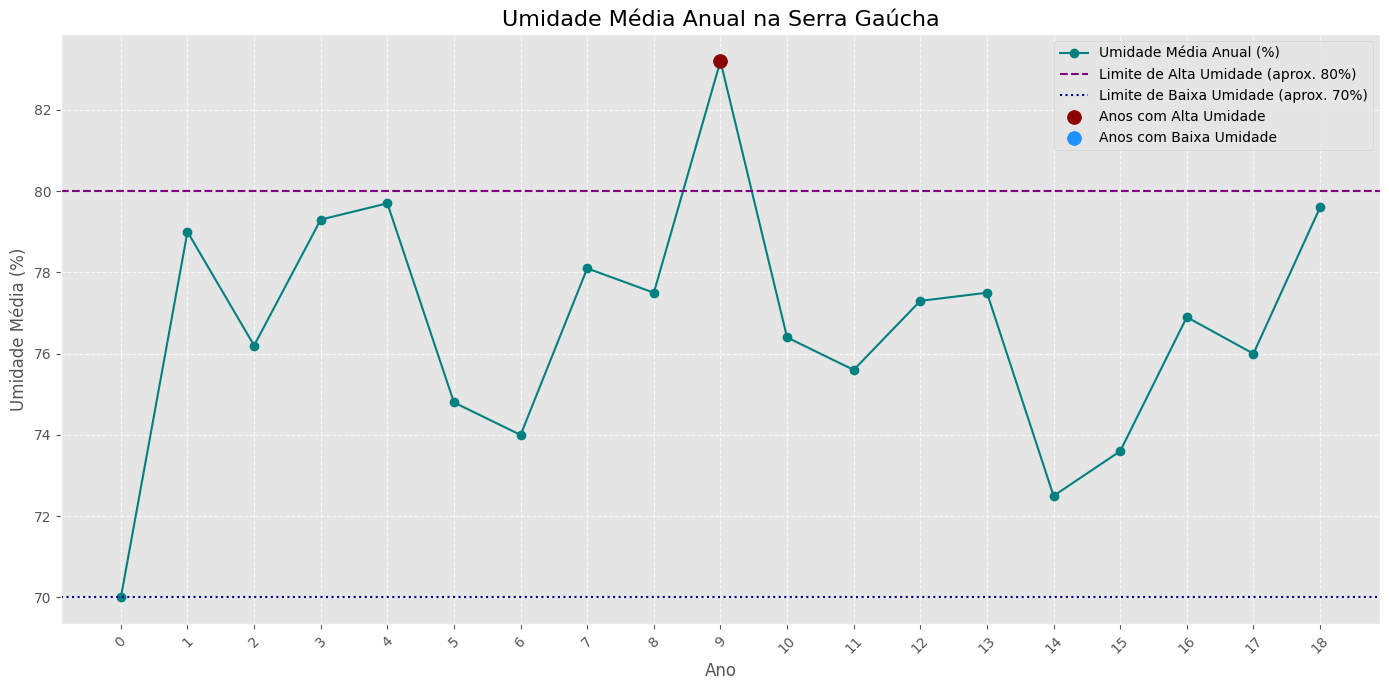


Anos com Umidade Média Anual acima do limite de alta umidade (> 80%):
[9]

Anos com Umidade Média Anual abaixo do limite de baixa umidade (< 70%):
[]


In [ ]:
# --- Gráfico 3: Umidade Média Anual com Faixas de Referência ---

fig, ax_umidade = plt.subplots(figsize=(14, 7))

# Plotar a umidade média
ax_umidade.plot(df_clima_para_graficos.index,
                df_clima_para_graficos['Umidade Media (%)'],
                marker='o', linestyle='-', color='teal',
                label='Umidade Média Anual (%)')

# Limites de umidade
limite_alta_umidade = 80 # %
limite_baixa_umidade = 70 # %

# Linhas de referência
ax_umidade.axhline(y=limite_alta_umidade, color='purple', linestyle='--',
                   label=f'Limite de Alta Umidade (aprox. {limite_alta_umidade}%)')
ax_umidade.axhline(y=limite_baixa_umidade, color='darkblue', linestyle=':',
                   label=f'Limite de Baixa Umidade (aprox. {limite_baixa_umidade}%)')

# Destacar anos fora dos limites
anos_alta_umidade = df_clima_para_graficos[df_clima_para_graficos['Umidade Media (%)'] > limite_alta_umidade]
anos_baixa_umidade = df_clima_para_graficos[df_clima_para_graficos['Umidade Media (%)'] < limite_baixa_umidade]

ax_umidade.scatter(anos_alta_umidade.index,
                   anos_alta_umidade['Umidade Media (%)'],
                   color='darkred', s=100, zorder=5, label='Anos com Alta Umidade')
ax_umidade.scatter(anos_baixa_umidade.index,
                   anos_baixa_umidade['Umidade Media (%)'],
                   color='dodgerblue', s=100, zorder=5, label='Anos com Baixa Umidade')

# Configurações do gráfico
ax_umidade.set_title('Umidade Média Anual na Serra Gaúcha', fontsize=16)
ax_umidade.set_xlabel('Ano', fontsize=12)
ax_umidade.set_ylabel('Umidade Média (%)', fontsize=12)
ax_umidade.set_xticks(df_clima_para_graficos.index.tolist())
ax_umidade.tick_params(axis='x', rotation=45, labelsize=10)
ax_umidade.xaxis.set_major_formatter(mticker.FormatStrFormatter('%d'))
ax_umidade.grid(True, linestyle='--', alpha=0.7)
ax_umidade.legend(loc='upper right')
plt.tight_layout()
plt.show()

print("\nAnos com Umidade Média Anual acima do limite de alta umidade (> 80%):")
print(anos_alta_umidade.index.tolist())
print("\nAnos com Umidade Média Anual abaixo do limite de baixa umidade (< 70%):")
print(anos_baixa_umidade.index.tolist())


Gerando Gráfico 4: Temperaturas Máxima e Mínima Absolutas Anuais...


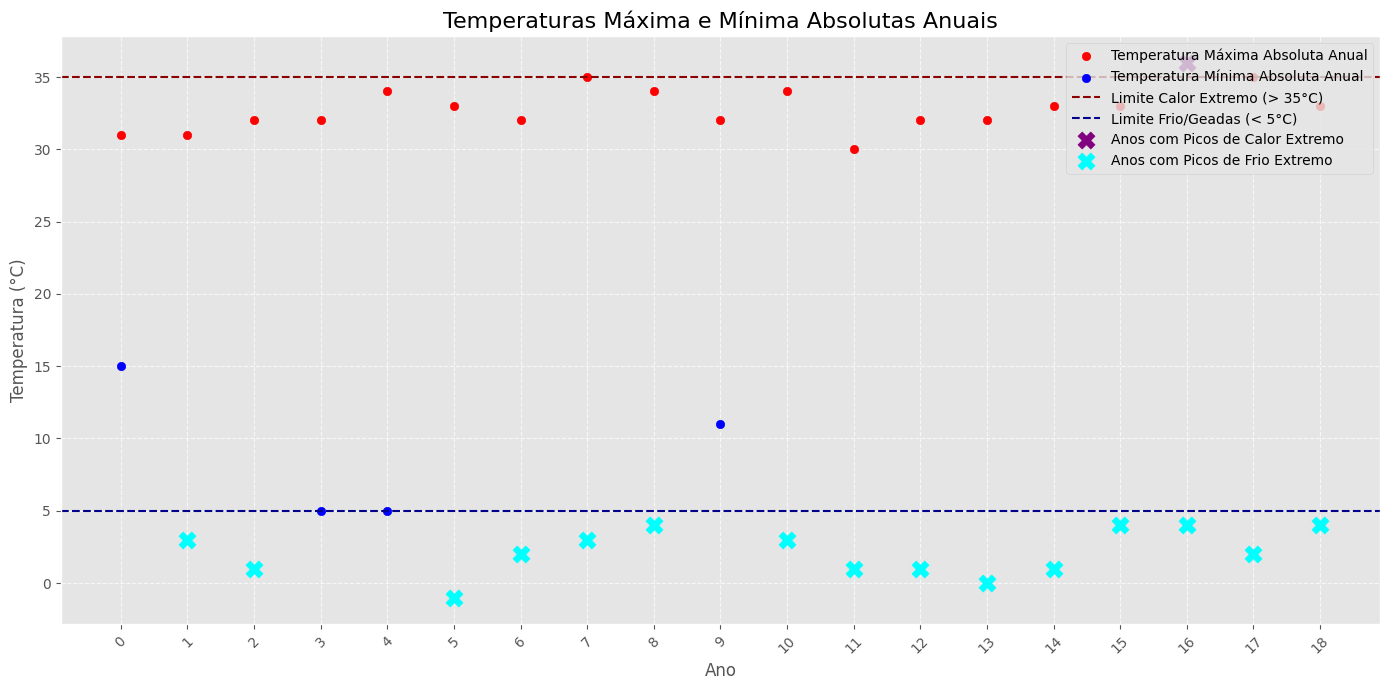


Anos com Temperatura Máxima Absoluta acima de 35°C:
[16]

Anos com Temperatura Mínima Absoluta abaixo de 5°C:
[1, 2, 5, 6, 7, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18]


In [ ]:
# --- Gráfico 4: Temperaturas Máxima e Mínima Absolutas Anuais ---
print("\nGerando Gráfico 4: Temperaturas Máxima e Mínima Absolutas Anuais...")

fig, ax_temp_extrema = plt.subplots(figsize=(14, 7))

# Limites para temperaturas extremas
limite_calor_extremo = 35 # °C
limite_frio_extremo = 5 # °C

# Plotar temperaturas máxima e mínima
ax_temp_extrema.scatter(df_clima_para_graficos.index,
                        df_clima_para_graficos['Temp Max Absoluta (°C)'],
                        color='red', label='Temperatura Máxima Absoluta Anual')
ax_temp_extrema.scatter(df_clima_para_graficos.index,
                        df_clima_para_graficos['Temp Min Absoluta (°C)'],
                        color='blue', label='Temperatura Mínima Absoluta Anual')

# Linhas de referência
ax_temp_extrema.axhline(y=limite_calor_extremo, color='darkred', linestyle='--',
                        label=f'Limite Calor Extremo (> {limite_calor_extremo}°C)')
ax_temp_extrema.axhline(y=limite_frio_extremo, color='darkblue', linestyle='--',
                        label=f'Limite Frio/Geadas (< {limite_frio_extremo}°C)')

# Destacar anos com temperaturas extremas
anos_calor_extremo = df_clima_para_graficos[df_clima_para_graficos['Temp Max Absoluta (°C)'] > limite_calor_extremo]
anos_frio_extremo = df_clima_para_graficos[df_clima_para_graficos['Temp Min Absoluta (°C)'] < limite_frio_extremo]

ax_temp_extrema.scatter(anos_calor_extremo.index,
                        anos_calor_extremo['Temp Max Absoluta (°C)'],
                        color='purple', s=150, marker='X', zorder=5, label='Anos com Picos de Calor Extremo')
ax_temp_extrema.scatter(anos_frio_extremo.index,
                        anos_frio_extremo['Temp Min Absoluta (°C)'],
                        color='cyan', s=150, marker='X', zorder=5, label='Anos com Picos de Frio Extremo')

# Configurações do gráfico
ax_temp_extrema.set_title('Temperaturas Máxima e Mínima Absolutas Anuais', fontsize=16)
ax_temp_extrema.set_xlabel('Ano', fontsize=12)
ax_temp_extrema.set_ylabel('Temperatura (°C)', fontsize=12)
ax_temp_extrema.set_xticks(df_clima_para_graficos.index.tolist())
ax_temp_extrema.tick_params(axis='x', rotation=45, labelsize=10)
ax_temp_extrema.xaxis.set_major_formatter(mticker.FormatStrFormatter('%d'))
ax_temp_extrema.grid(True, linestyle='--', alpha=0.7)
ax_temp_extrema.legend(loc='upper right')
plt.tight_layout()
plt.show()

print("\nAnos com Temperatura Máxima Absoluta acima de 35°C:")
print(anos_calor_extremo.index.tolist())
print("\nAnos com Temperatura Mínima Absoluta abaixo de 5°C:")
print(anos_frio_extremo.index.tolist())

# Clima 2

Arquivo CSV carregado com sucesso.
Colunas originais: ['Data Medicao', 'PRECIPITACAO TOTAL, DIARIO (AUT)(mm)', 'TEMPERATURA MAXIMA, DIARIA (AUT)(°C)', 'TEMPERATURA MEDIA, DIARIA (AUT)(°C)', 'TEMPERATURA MINIMA, DIARIA (AUT)(°C)', 'UMIDADE RELATIVA DO AR, MEDIA DIARIA (AUT)(%)', 'VENTO, VELOCIDADE MEDIA DIARIA (AUT)(m/s)', 'Unnamed: 7']
Colunas após tentativa de renomeação: ['Data', 'Precipitacao', 'Temp_Max', 'Temp_Media', 'Temp_Min', 'Umidade', 'Vento', 'Unnamed: 7']

Dados filtrados para o período de 2014-01-01 a 2023-12-31 (Total de 3652 registros).

Gerando gráficos...
Plotando Temperatura Média...


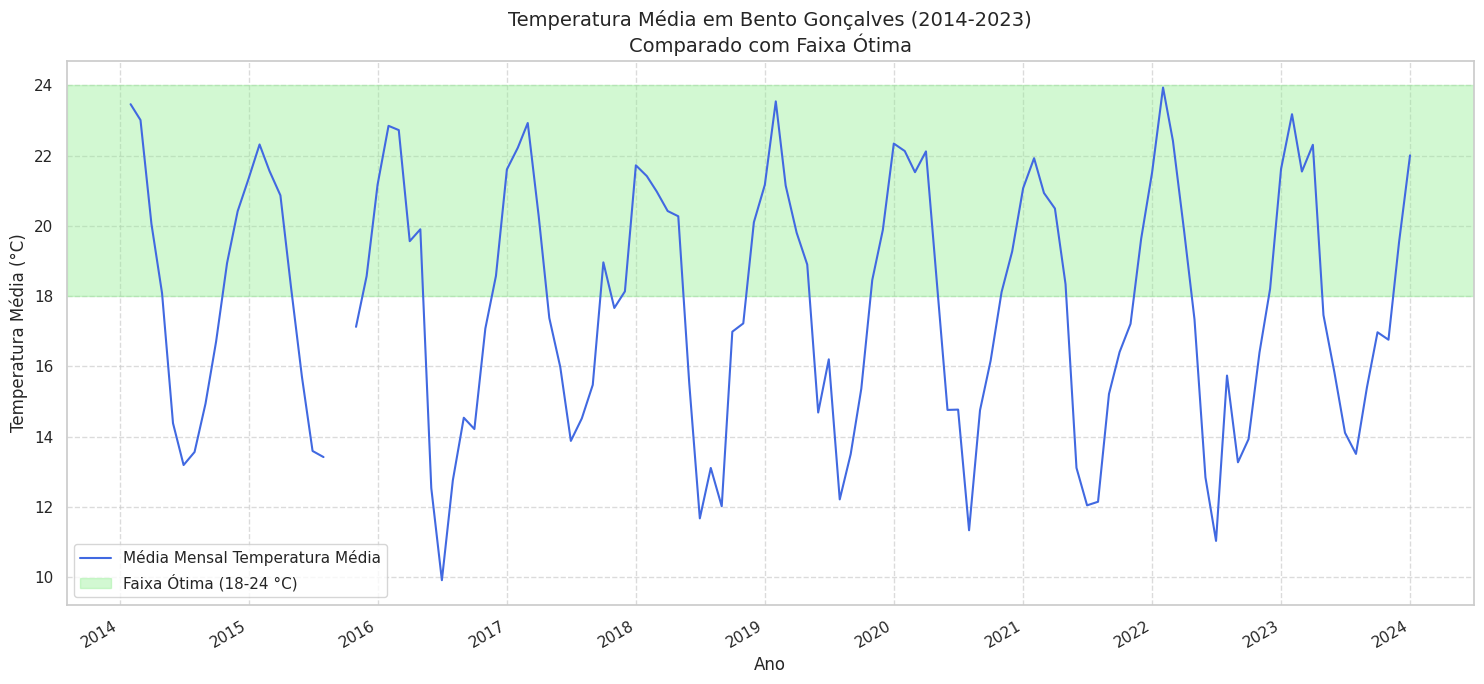

Plotando Temperatura Máxima...


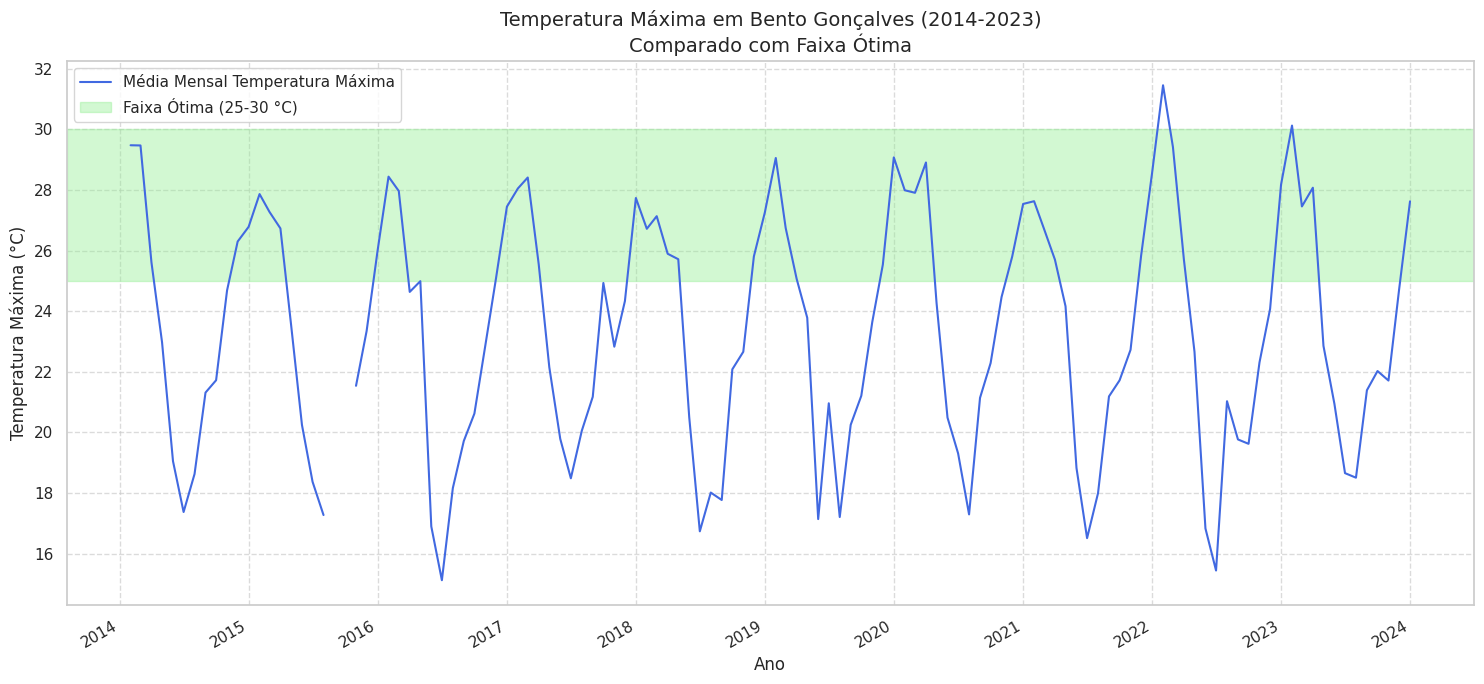

Plotando Temperatura Mínima...


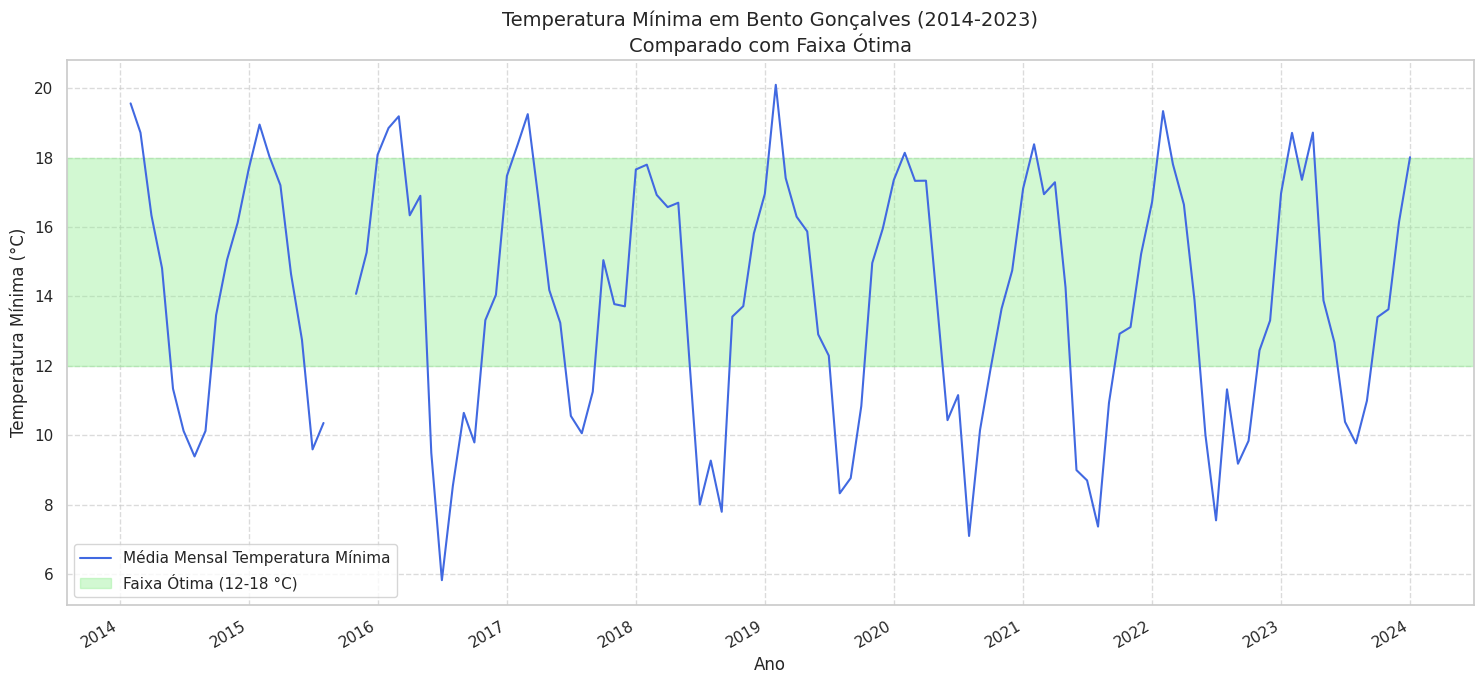

Plotando Umidade Relativa Média...


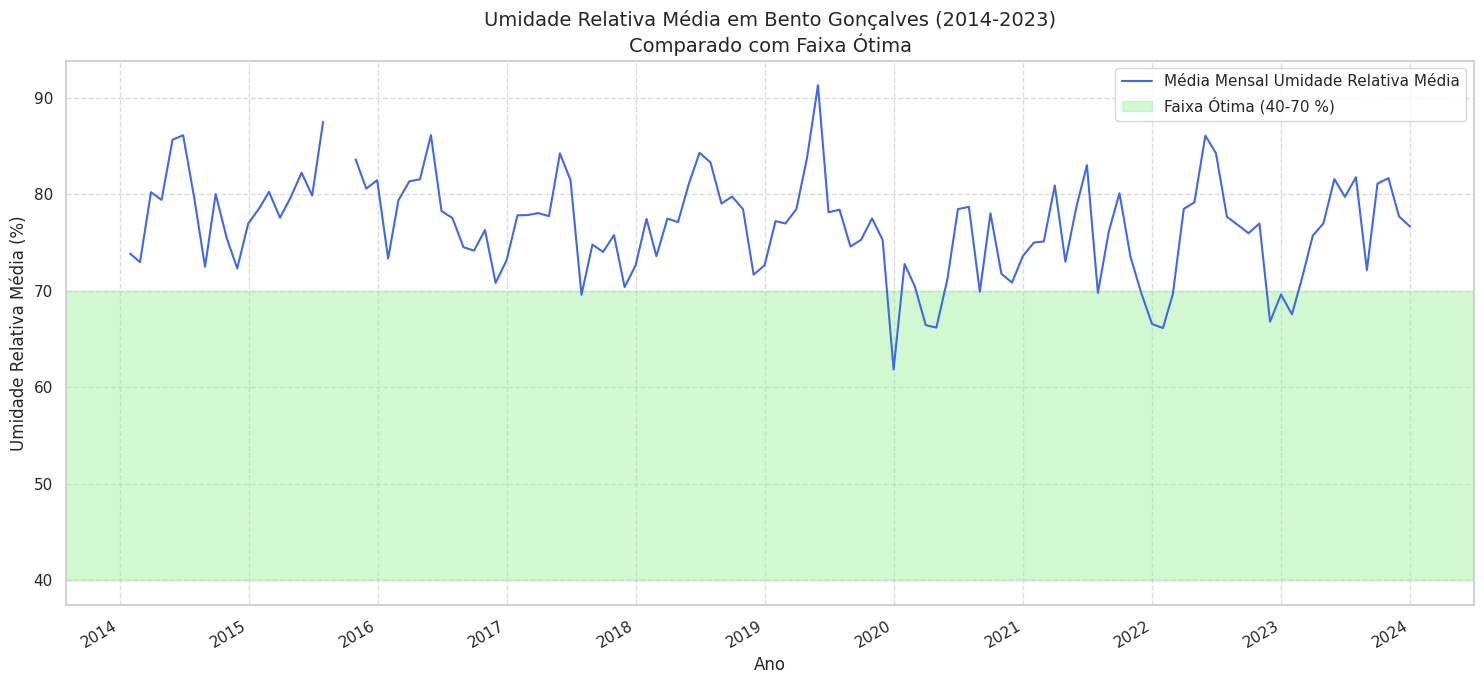

Plotando Velocidade Média do Vento...


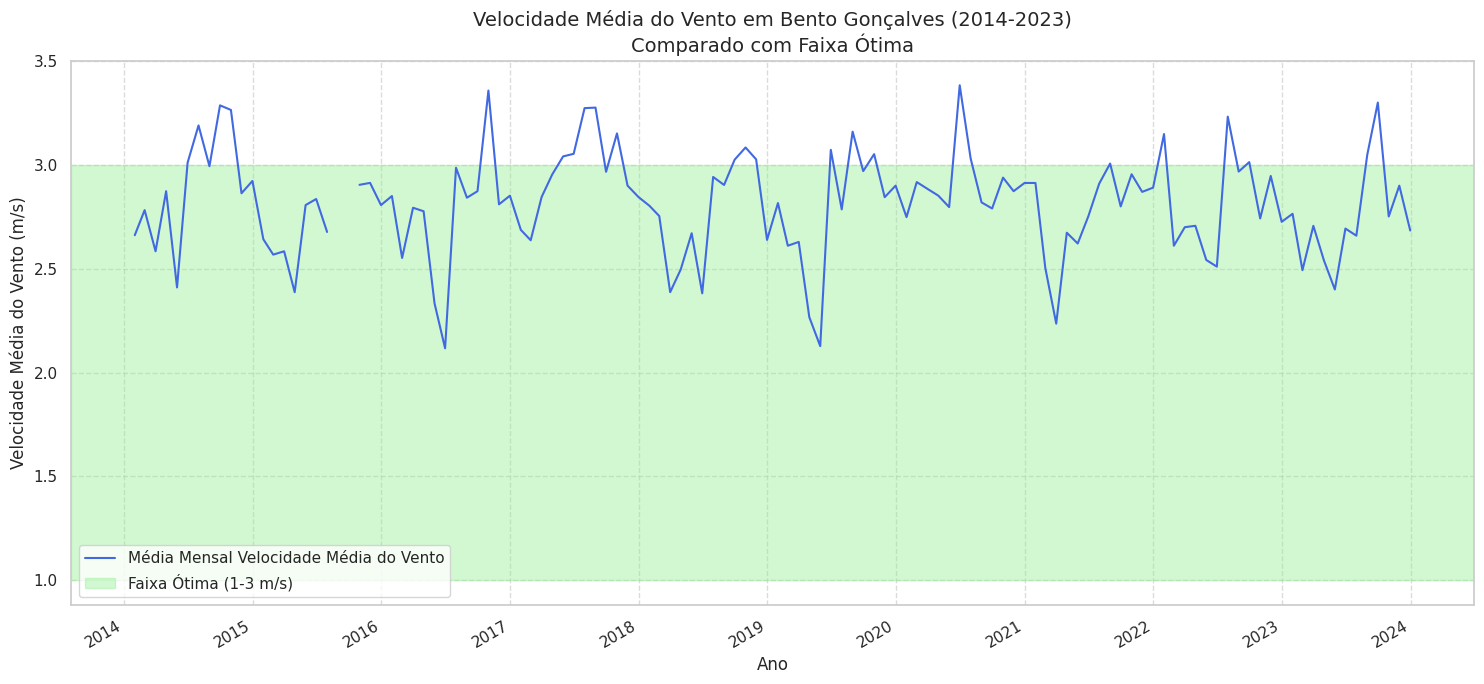


Análise concluída.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# --- 1. Configurações Iniciais ---
file_path = 'https://raw.githubusercontent.com/jaqueantunes/export_uva/refs/heads/main/Bases%20externas/Clima%20-%20INMET%20-%20RS/dados_A840_D_2006-11-30_2024-12-31.csv' # Certifique-se que este arquivo está no mesmo diretório
start_date_period = '2014-01-01'
end_date_period = '2023-12-31'
city_name = "Bento Gonçalves" # Para os títulos dos gráficos

# Definição das faixas ótimas (baseado em exemplos anteriores ou conhecimento geral)
optimal_ranges = {
    'Temp_Media': (18, 24), # °C - Conforto térmico geral
    'Temp_Max': (25, 30),   # °C - Agradável para atividades ao ar livre
    'Temp_Min': (12, 18),   # °C - Confortável para noites
    'Umidade': (40, 70),    # %  - Ideal para saúde e conforto
    'Vento': (1, 3)         # m/s - Vento leve a moderado
}
units = {
    'Temp_Media': '°C',
    'Temp_Max': '°C',
    'Temp_Min': '°C',
    'Umidade': '%',
    'Vento': 'm/s'
}
plot_titles_pt = {
    'Temp_Media': 'Temperatura Média',
    'Temp_Max': 'Temperatura Máxima',
    'Temp_Min': 'Temperatura Mínima',
    'Umidade': 'Umidade Relativa Média',
    'Vento': 'Velocidade Média do Vento'
}

# Configuração de estilo dos gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 7) # Tamanho padrão das figuras

# --- 2. Carregamento e Pré-processamento dos Dados ---
try:
    # Pular as primeiras 8 linhas de metadados e ler o CSV
    # Usar engine='python' pode ser necessário se houver problemas com skipfooter ou parsing complexo
    df = pd.read_csv(file_path, skiprows=10, sep=';', decimal=',', na_values=['null', 'NULL', '-'])
    print("Arquivo CSV carregado com sucesso.")
    print("Colunas originais:", df.columns.tolist())
except FileNotFoundError:
    print(f"ERRO: O arquivo '{file_path}' não foi encontrado. Verifique o caminho.")
    exit()
except Exception as e:
    print(f"ERRO ao ler o arquivo CSV: {e}")
    exit()

# Renomear colunas para facilitar o trabalho
# Estes são nomes comuns em dados diários do INMET; ajuste se necessário
columns_to_rename = {
    'Data Medicao': 'Data', # Nome comum para coluna de data
    'PRECIPITACAO TOTAL, DIARIO (AUT)(mm)': 'Precipitacao',
    'TEMPERATURA MAXIMA, DIARIA (AUT)(°C)': 'Temp_Max',
    'TEMPERATURA MEDIA, DIARIA (AUT)(°C)': 'Temp_Media',
    'TEMPERATURA MINIMA, DIARIA (AUT)(°C)': 'Temp_Min',
    'UMIDADE RELATIVA DO AR, MEDIA DIARIA (AUT)(%)': 'Umidade',
    'VENTO, VELOCIDADE MEDIA DIARIA (AUT)(m/s)': 'Vento'
}

# Renomear apenas as colunas que existem no DataFrame
actual_renames = {k: v for k, v in columns_to_rename.items() if k in df.columns}
df.rename(columns=actual_renames, inplace=True)
print("Colunas após tentativa de renomeação:", df.columns.tolist())

# Verificar se a coluna de Data existe
if 'Data' not in df.columns:
    print("ERRO: Coluna 'Data' (esperada para data/medição) não encontrada após renomeação.")
    print(f"Verifique os nomes das colunas originais e o mapeamento em 'columns_to_rename'.")
    exit()

# Converter a coluna de data para datetime
try:
    df['Data'] = pd.to_datetime(df['Data'], format='%Y-%m-%d')
except Exception as e:
    print(f"ERRO ao converter a coluna 'Data' para datetime: {e}")
    print("Verifique o formato da data na coluna e no pd.to_datetime.")
    exit()

# Definir a coluna 'Data' como índice
df.set_index('Data', inplace=True)

# Selecionar as colunas de interesse para conversão numérica e análise
cols_of_interest = ['Temp_Media', 'Temp_Max', 'Temp_Min', 'Umidade', 'Vento']
existing_cols_of_interest = [col for col in cols_of_interest if col in df.columns]

# Converter colunas para numérico, tratando erros
for col in existing_cols_of_interest:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Filtrar para o período desejado (últimos 10 anos especificados)
df_filtered = df.loc[start_date_period:end_date_period].copy()

if df_filtered.empty:
    print(f"ERRO: Nenhum dado encontrado para o período de {start_date_period} a {end_date_period}.")
    exit()

print(f"\nDados filtrados para o período de {start_date_period} a {end_date_period} (Total de {len(df_filtered)} registros).")

# --- 3. Função para Plotagem ---
def plot_clima_com_faixa_otima(data_series, var_name, unit, optimal_range, title_pt, cidade):
    """
    Plota uma série temporal (média mensal) de dados climáticos com sua faixa ótima.
    """
    if data_series.empty or data_series.isnull().all():
        print(f"Não há dados para plotar para {title_pt}.")
        return

    # Calcular média mensal para suavizar e melhor visualização de tendências anuais
    monthly_avg = data_series.resample('ME').mean() # 'ME' para frequência de fim de mês

    plt.figure() # Garante uma nova figura para cada plot
    plt.plot(monthly_avg.index, monthly_avg, label=f'Média Mensal {title_pt}', color='royalblue', linewidth=1.5)

    # Adicionar faixa ótima
    if optimal_range:
        plt.axhspan(optimal_range[0], optimal_range[1], color='lightgreen', alpha=0.4, label=f'Faixa Ótima ({optimal_range[0]}-{optimal_range[1]} {unit})')

    plt.title(f'{title_pt} em {cidade} ({monthly_avg.index.year.min()}-{monthly_avg.index.year.max()})\nComparado com Faixa Ótima', fontsize=14)
    plt.ylabel(f'{title_pt} ({unit})', fontsize=12)
    plt.xlabel('Ano', fontsize=12)

    # Formatar eixo X para mostrar anos claramente
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y')) # Mostrar apenas o ano
    plt.gca().xaxis.set_major_locator(mdates.YearLocator(base=1)) # Marcar cada ano
    plt.gcf().autofmt_xdate() # Rotacionar datas para melhor visualização

    plt.legend(loc='best')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# --- 4. Gerar Gráficos ---
print("\nGerando gráficos...")

for var_key in existing_cols_of_interest:
    if var_key in df_filtered.columns:
        print(f"Plotando {plot_titles_pt[var_key]}...")
        plot_clima_com_faixa_otima(
            data_series=df_filtered[var_key],
            var_name=var_key,
            unit=units[var_key],
            optimal_range=optimal_ranges[var_key],
            title_pt=plot_titles_pt[var_key],
            cidade=city_name
        )
    else:
        print(f"AVISO: Coluna '{var_key}' (esperada para {plot_titles_pt[var_key]}) não encontrada nos dados filtrados. Gráfico não gerado.")

print("\nAnálise concluída.")

Exportação x clima